<a href="https://colab.research.google.com/github/GilliardMorandim/mba-tcc-usp-inadimplencia/blob/eda%2Ffeature/analise_sobrevivencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark
!pip install mlxtend
!pip install lifelines
!pip install imblearn
!pip install scikit-survival


E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/o/openjdk-lts/openjdk-11-jre-headless_11.0.29%2b7-1ubuntu1%7e22.04_amd64.deb  404  Not Found [IP: 91.189.91.83 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/o/openjdk-lts/openjdk-11-jdk-headless_11.0.29%2b7-1ubuntu1%7e22.04_amd64.deb  404  Not Found [IP: 91.189.91.83 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=be64086d34a73bba51c0164772760fb314185722aee1e19966df9a238c1f180b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os

import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
import pymc as pm
import arviz as az

import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
import arviz as az

from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter, CoxPHFitter
#from survivepy.metrics import brier_score
from lifelines.statistics import logrank_test

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Import the required libraries for model training
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, recall_score, roc_auc_score, classification_report,ConfusionMatrixDisplay,roc_curve,auc

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

import gc
from sksurv.ensemble import RandomSurvivalForest
from pyspark.ml.classification import RandomForestClassifier
#from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sksurv.util import Surv

from matplotlib.artist import get
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

#Analise de Sobrevivencia
from lifelines import KaplanMeierFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

import pymc as pm
import os
from sklearn.utils import resample

import time
from datetime import datetime




import warnings
warnings.filterwarnings('ignore')

# Modelos de sobrevivência
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, brier_score, cumulative_dynamic_auc

drive.mount('/content/drive')

Mounted at /content/drive


# Baixar Dados

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, when
from pyspark.sql.functions import try_divide

spark = (SparkSession.builder
         .appName("LoadAllCSVs")\
         .config("spark.driver.memory", "8g")
         .config("spark.executor.memory", "8g")
         .config("spark.sql.files.maxPartitionBytes", "256m")
         .getOrCreate())

print("Spark iniciado!")

Spark iniciado!


In [6]:


# Configuração do caminho
base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"
file_name = "parcelas_main_aux_all_columns.csv"
full_path = os.path.join(base_path, file_name)

print(f"📥 Lendo via PySpark: {file_name}")

try:
    # Leitura direta do arquivo específico
    df_parcelas = (spark.read
                  .option("header", "true")
                  .option("inferSchema", "true")
                  .csv(full_path))

    # Exibição de métricas básicas
    print(f"✔ OK - Linhas: {df_parcelas.count()} | Colunas: {len(df_parcelas.columns)}")

    # Opcional: Criar uma view temporária para usar com SparkSQL
    df_parcelas.createOrReplaceTempView("parcelas_main")

except Exception as e:
    print(f"❌ Erro ao ler {file_name}: {e}")

# Agora você pode acessar os dados diretamente pela variável df_parcelas

parcelas_main_aux_all_columns = df_parcelas

📥 Lendo via PySpark: parcelas_main_aux_all_columns.csv
✔ OK - Linhas: 1063816 | Colunas: 36


In [ ]:
dfs_spark = {}

base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"

files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

for file in files:
    full_path = os.path.join(base_path, file)
    print(f"\n📥 Lendo via PySpark: {file}")

    try:
        df = (spark.read
              .option("header", "true")
              .option("inferSchema", "true")
              .csv(full_path))

        key = file.replace(".csv", "")
        dfs_spark[key] = df

        print(f"✔ OK - Linhas (estimado pela Spark): {df.count()} | Colunas: {len(df.columns)}")

    except Exception as e:
        print(f"❌ Erro ao ler {file}: {e}")

print("\nTodos os arquivos foram processados!")

globals().update(dfs_spark)


📥 Lendo via PySpark: pre_aprovado.csv
✔ OK - Linhas (estimado pela Spark): 42171363 | Colunas: 11

📥 Lendo via PySpark: parcelas.csv
✔ OK - Linhas (estimado pela Spark): 1865444 | Colunas: 21

📥 Lendo via PySpark: contratos.csv
✔ OK - Linhas (estimado pela Spark): 382539 | Colunas: 26

📥 Lendo via PySpark: score_credito.csv
✔ OK - Linhas (estimado pela Spark): 266126 | Colunas: 3

📥 Lendo via PySpark: analise_conversao.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v2.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v3.csv
✔ OK - Linhas (estimado pela Spark): 533525 | Colunas: 11

📥 Lendo via PySpark: parcelas_main_pd_filtrado.csv
✔ OK - Linhas (estimado pela Spark): 1063816 | Colunas: 17

📥 Lendo via PySpark: Tabela_Hash_Enriquecida.csv
✔ OK - Linhas (estimado pela Spark): 104228 | Colunas: 1

📥 Lendo via PySpark: resultados_modelos_classicos.csv
✔ OK - Linhas (estimado pela Sp

#Referencias

- https://www.kaggle.com/code/henriquebas/people-analytics-turnover-python-lifelines
- https://www.datacamp.com/pt/tutorial/weibull-distribution
- https://statplace.com.br/blog/como-fazer-analise-de-sobrevivencia-na-pratica/

# Distribuição Weibull

In [7]:
parcelas_main_aux_all_columns.show(5, truncate=False)

+--------------------------------------+--------------+---------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------------------------+-------+------------------+-------------------------------+--------------------------------------+--------------------------------------+---------------+----------------------------------------------------------------+----------------+------------------+---------------------------+--------------------------------+---------------------+--------------------------+--------------------------+----+-----+---------+---------------+
|id_contrato                           |data_pagamento|data_vencimento|valor  |valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_a

# Distribuição Log-Normal

# Pipeline

In [ ]:
class SurvivalPipeline:
    def __init__(
        self,
        duration_col,   # coluna de tempo (ex: parcelas)
        event_col,      # indicador de evento
        covariates,
        scale_covariates=True,
        draws=2000
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.scale_covariates = scale_covariates

        self.scaler = StandardScaler() if scale_covariates else None
        self.models = {}
        self.results = {}

    def _prepare_data(self, df):
        data = df[[self.duration_col, self.event_col] + self.covariates].copy()

        if self.scale_covariates:
            data[self.covariates] = self.scaler.fit_transform(
                data[self.covariates]
            )

        return data

    def fit(self, df):
        data = self._prepare_data(df_train, fit_scaler=True)

        weibull = WeibullAFTFitter()
        weibull.fit(
            data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        lognormal = LogNormalAFTFitter()
        lognormal.fit(
            data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        self.models["weibull"] = weibull
        self.models["lognormal"] = lognormal

        self._evaluate_models()

        return self

    def _evaluate_models(self):
        for name, model in self.models.items():
            self.results[name] = {
                "AIC": model.AIC_,
                "LogLikelihood": model.log_likelihood_
            }

    def compare_models(self):
        return pd.DataFrame(self.results).T.sort_values("AIC")

    def summary(self, model_name):
        return self.models[model_name].summary

    def predict_survival(self, model_name, X, times):
        model = self.models[model_name]

        if self.scale_covariates:
            X_scaled = pd.DataFrame(
                self.scaler.transform(X),
                columns=self.covariates
            )
        else:
            X_scaled = X.copy()

        return model.predict_survival_function(X_scaled, times=times)

    def predict_pd(self, model_name, X, times):
        survival = self.predict_survival(model_name, X, times)
        return 1 - survival

    def predict_hazard(self, model_name, X):
        model = self.models[model_name]
        return model.predict_hazard_ratios(X)

    def predict_median(self, model_name, X):
        model = self.models[model_name]
        return model.predict_median(X)

# Transformando spark em Pandas

In [8]:
survival_df = parcelas_main_aux_all_columns.toPandas()

survival_df = survival_df[["qtd_dias_de_atraso_v2", "flag_inadimplencia_30_days", "flag_inadimplencia_90_days", "parcela_norm_0_1","parcela", "valor_parcela","valor_financiado_principal_iof",
                                             "valor_pago","valor_juros_atraso","qtd_parcelas", "pct_juros", "pct_amortizacao"]].copy()

In [9]:
survival_df = survival_df.dropna()

survival_df["flag_inadimplencia_30_days"] = (
    survival_df["flag_inadimplencia_30_days"].astype(int)
)

survival_df["qtd_dias_de_atraso_v2"] = (survival_df["qtd_dias_de_atraso_v2"].clip(lower=1)) # essencial para rodar o modelo bayesiano


In [10]:
covariates = ["parcela_norm_0_1","parcela", "valor_parcela","valor_financiado_principal_iof",
                                             "valor_pago","valor_juros_atraso","qtd_parcelas", "pct_juros", "pct_amortizacao" ]


# Survival Pipeline

In [ ]:
class SurvivalPipeline:
    def __init__(self, duration_col, event_col, covariates, scale_covariates=True):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.scale_covariates = scale_covariates
        self.scaler = StandardScaler() if scale_covariates else None
        self.models = {}

        self.train_data = None
        self.test_data = None

    def _prepare_data(self, df, fit_scaler=False):
        data = df[[self.duration_col, self.event_col] + self.covariates].copy()

        if self.scale_covariates:
            if fit_scaler:
                data[self.covariates] = self.scaler.fit_transform(
                    data[self.covariates]
                )
            else:
                data[self.covariates] = self.scaler.transform(
                    data[self.covariates]
                )

        return data

    def fit(self, df_train, df_test=None):
        """
        Treina modelos de sobrevivência clássicos
        """
        self.train_data = self._prepare_data(df_train, fit_scaler=True)

        if df_test is not None:
            self.test_data = self._prepare_data(df_test, fit_scaler=False)

        # Weibull
        weibull = WeibullAFTFitter()
        weibull.fit(
            self.train_data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        # LogNormal
        lognormal = LogNormalAFTFitter()
        lognormal.fit(
            self.train_data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        self.models["Weibull"] = weibull
        self.models["LogNormal"] = lognormal

        return self

    def compare_models(self):
        """
        Compara modelos via AIC (treino)
        """
        if self.train_data is None:
            raise ValueError("O pipeline precisa ser treinado antes.")

        print("\n" + "=" * 40)
        print("COMPARAÇÃO DE MODELOS – AIC")
        print("=" * 40)

        results = {}

        for name, model in self.models.items():
            aic = model.AIC_
            results[name] = aic
            print(f"{name}: AIC = {aic:.2f}")

        return results


# Treino e Teste

In [11]:
cols_model = [
    "qtd_dias_de_atraso_v2",
    "flag_inadimplencia_90_days",
    "valor_parcela",
    "pct_juros",
    "pct_amortizacao",
    "parcela_norm_0_1"
]

survival_df_model = survival_df[cols_model].dropna()
survival_df_model = survival_df_model[survival_df_model["qtd_dias_de_atraso_v2"] > 0]

survival_df_model = survival_df_model.astype({
    "qtd_dias_de_atraso_v2": "int16",
    "flag_inadimplencia_90_days": "int8",
    "valor_parcela": "float32",
    "pct_juros": "float32",
    "pct_amortizacao": "float32",
    "parcela_norm_0_1": "float32"
})

#-------------------------------------------------------------------------------------------------------#
NOME_COLUNA_TEMPO = 'qtd_dias_de_atraso_v2'
NOME_COLUNA_EVENTO = 'flag_inadimplencia_90_days'
#-------------------------------------------------------------------------------------------------------#

X_features = survival_df_model[["valor_parcela","pct_juros","pct_amortizacao","parcela_norm_0_1"]].copy()
#Y_target = survival_df_model[["flag_inadimplencia_90_days"]].copy()
#-------------------------------------------------------------------------------------------------------#
evento_bool = survival_df_model[NOME_COLUNA_EVENTO].astype(bool)
tempo_float = survival_df_model[NOME_COLUNA_TEMPO].astype(float)
Y_target = Surv.from_arrays(event=evento_bool, time=tempo_float)

# Normalização das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Divisão em Treino e Teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_target, test_size=0.25, random_state=42,
    stratify=survival_df_model["flag_inadimplencia_90_days"]
)
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")
#-------------------------------------------------------------------------------------------------------#

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.


In [ ]:
Y_train

array([(False,  3.), (False,  7.), (False, 61.), ..., (False, 59.),
       (False,  1.), (False, 30.)],
      dtype=[('event', '?'), ('time', '<f8')])

In [ ]:
pipeline = SurvivalPipeline(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_30_days",
    covariates=covariates,
    scale_covariates=True
)

pipeline.fit(survival_df)
pipeline.compare_models()


COMPARAÇÃO DE MODELOS – AIC
Weibull: AIC = 2148552.45
LogNormal: AIC = 2225878.09


{'Weibull': np.float64(2148552.4504324617),
 'LogNormal': np.float64(2225878.094249465)}

# Analise Weibull vs Log-Normal

In [ ]:
pipeline.summary("weibull")


coef  exp(coef)  se(coef)  \
param   covariate                                                       
lambda_ parcela                         0.501434   1.651088  0.001231   
        parcela_norm_0_1                0.025125   1.025444  0.001007   
        pct_amortizacao                -0.060758   0.941051  0.001124   
        pct_juros                      -0.006666   0.993356  0.001644   
        qtd_parcelas                   -0.035000   0.965606  0.002144   
        valor_financiado_principal_iof  0.000034   1.000034  0.001374   
        valor_juros_atraso              0.119870   1.127350  2.743311   
        valor_pago                     -0.037365   0.963325  0.001029   
        valor_parcela                   0.009368   1.009412  0.001399   
        Intercept                       4.091492  59.829104  0.516380   
rho_    Intercept                       1.447176   4.251090  0.001582   

                                        coef lower 95%  coef upper 95%  \
param   covariate                                                        
lambda_ parcela                               0.499021        0.503848   
        parcela_norm_0_1                      0.023152        0.027099   
        pct_amortizacao                      -0.062961       -0.058555   
        pct_juros                            -0.009889       -0.003444   
        qtd_parcelas                         -0.039203       -0.030797   
        valor_financiado_principal_iof       -0.002658        0.002726   
        valor_juros_atraso                   -5.256921        5.496661   
        valor_pago                           -0.039382       -0.035347   
        valor_parcela                         0.006626        0.012110   
        Intercept                             3.079406        5.103579   
rho_    Intercept                             1.444074        1.450277   

                                        exp(coef) lower 95%  \
param   covariate                                             
lambda_ parcela                                    1.647109   
        parcela_norm_0_1                           1.023422   
        pct_amortizacao                            0.938980   
        pct_juros                                  0.990160   
        qtd_parcelas                               0.961556   
        valor_financiado_principal_iof             0.997345   
        valor_juros_atraso                         0.005211   
        valor_pago                                 0.961383   
        valor_parcela                              1.006648   
        Intercept                                 21.745479   
rho_    Intercept                                  4.237927   

                                        exp(coef) upper 95%  cmp to  \
param   covariate                                                     
lambda_ parcela                                    1.655077     0.0   
        parcela_norm_0_1                           1.027469     0.0   
        pct_amortizacao                            0.943126     0.0   
        pct_juros                                  0.996562     0.0   
        qtd_parcelas                               0.969672     0.0   
        valor_financiado_principal_iof             1.002729     0.0   
        valor_juros_atraso                       243.876174     0.0   
        valor_pago                                 0.965270     0.0   
        valor_parcela                              1.012184     0.0   
        Intercept                                164.609929     0.0   
rho_    Intercept                                  4.264294     0.0   

                                                 z              p    -log2(p)  
param   covariate                                                              
lambda_ parcela                         407.278920   0.000000e+00         inf  
        parcela_norm_0_1                 24.953872  1.938407e-137  454.149278  
        pct_amortizacao                 -54.058097   0.000000e+00  

In [ ]:
pipeline.summary("lognormal")


coef  exp(coef)     se(coef)  \
param  covariate                                                          
mu_    parcela                         0.449530   1.567575     0.001814   
       parcela_norm_0_1                0.008917   1.008957     0.001284   
       pct_amortizacao                -0.064314   0.937710     0.001587   
       pct_juros                       0.005695   1.005711     0.002548   
       qtd_parcelas                   -0.051920   0.949404     0.003332   
       valor_financiado_principal_iof  0.001630   1.001631     0.001796   
       valor_juros_atraso              0.267481   1.306669  7545.638474   
       valor_pago                     -0.094932   0.909435     0.001288   
       valor_parcela                   0.022661   1.022919     0.001782   
       Intercept                       3.988881  53.994434  1420.332853   
sigma_ Intercept                      -1.045717   0.351440     0.001404   

                                       coef lower 95%  coef upper 95%  \
param  covariate                                                        
mu_    parcela                               0.445975        0.453084   
       parcela_norm_0_1                      0.006401        0.011433   
       pct_amortizacao                      -0.067425       -0.061204   
       pct_juros                             0.000701        0.010689   
       qtd_parcelas                         -0.058450       -0.045390   
       valor_financiado_principal_iof       -0.001891        0.005151   
       valor_juros_atraso               -14788.912168    14789.447131   
       valor_pago                           -0.097457       -0.092407   
       valor_parcela                         0.019168        0.026153   
       Intercept                         -2779.812357     2787.790119   
sigma_ Intercept                            -1.048469       -1.042966   

                                       exp(coef) lower 95%  \
param  covariate                                             
mu_    parcela                                    1.562013   
       parcela_norm_0_1                           1.006421   
       pct_amortizacao                            0.934798   
       pct_juros                                  1.000701   
       qtd_parcelas                               0.943225   
       valor_financiado_principal_iof             0.998111   
       valor_juros_atraso                         0.000000   
       valor_pago                                 0.907141   
       valor_parcela                              1.019353   
       Intercept                                  0.000000   
sigma_ Intercept                                  0.350474   

                                       exp(coef) upper 95%  cmp to  \
param  covariate                                                     
mu_    parcela                                    1.573157     0.0   
       parcela_norm_0_1                           1.011499     0.0   
       pct_amortizacao                            0.940632     0.0   
       pct_juros                                  1.010747     0.0   
       qtd_parcelas                               0.955625     0.0   
       valor_financiado_principal_iof             1.005164     0.0   
       valor_juros_atraso                              inf     0.0   
       valor_pago                                 0.911734     0.0   
       valor_parcela                              1.026498     0.0   
       Intercept                                       inf     0.0   
sigma_ Intercept                                  0.352408     0.0   

                                                z             p    -log2(p)  
param  covariate                                                             
mu_    parcela                         247.878725  0.000000e+00         inf  
       parcela_norm_0_1                  6.945688  3.766212e-12   37.950023  
       pct_amortizacao                 -40.520227  0.000000e+00         inf  
       pc

In [ ]:
X_new = survival_df[covariates].iloc[:1]

times = np.arange(1, 181, 30)

pd_curve = pipeline.predict_pd(
    model_name="weibull",
    X=X_new,
    times=times
)


# Curva de Sobrevivência - Weibull

In [ ]:
def plot_survival_curve(pipeline, model_name, X, max_time=360):
    times = np.arange(1, max_time + 1)

    survival = pipeline.predict_survival(
        model_name=model_name,
        X=X,
        times=times)

    plt.figure(figsize=(10, 6))
    plt.plot(times, survival.iloc[:,0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade de Sobrevivência")
    plt.title(f"Curva de Sobrevivência - {model_name.upper()}")
    plt.grid(True)
    plt.show()

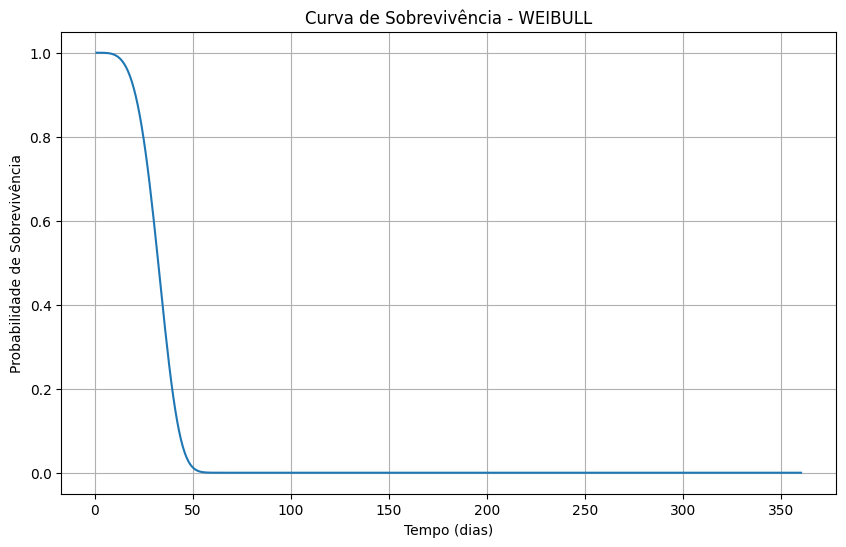

In [ ]:
X_ref = survival_df[covariates].iloc[[0]]
plot_survival_curve(pipeline, "weibull", X_ref)

# Curva de Probabilidade de Inadimplência (PD(t))

In [ ]:
def plot_pd_curve(pipeline, model_name, X, max_time=180):
    times = np.arange(1, max_time + 1)

    pd_curve = pipeline.predict_pd(
        model_name=model_name,
        X=X,
        times=times
    )

    plt.figure(figsize=(8, 5))
    plt.plot(times, pd_curve.iloc[:, 0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title(f"PD(t) — {model_name.capitalize()}")
    plt.grid(True)
    plt.show()


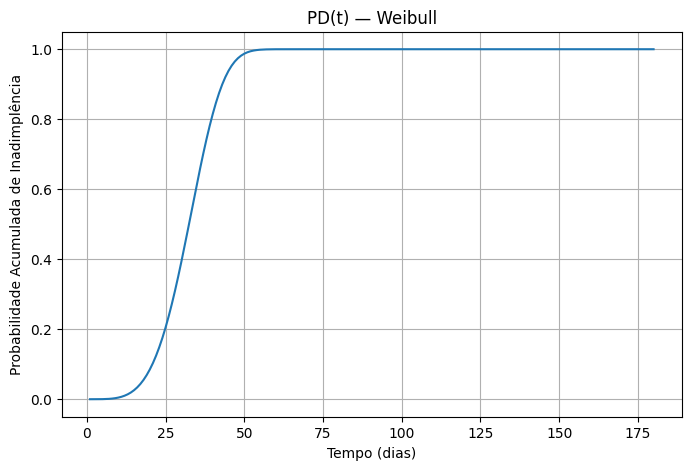

In [ ]:
plot_pd_curve(pipeline, "weibull", X_ref)


# Comparação Weibull vs Log-Normal (PD)

In [ ]:
def plot_model_comparison(pipeline, X, max_time=180):
    times = np.arange(1, max_time + 1)

    pd_weibull = pipeline.predict_pd("weibull", X, times)
    pd_lognormal = pipeline.predict_pd("lognormal", X, times)

    plt.figure(figsize=(8, 5))
    plt.plot(times, pd_weibull.iloc[:, 0], label="Weibull")
    plt.plot(times, pd_lognormal.iloc[:, 0], label="Log-Normal")

    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title("Comparação de Modelos — PD(t)")
    plt.legend()
    plt.grid(True)
    plt.show()


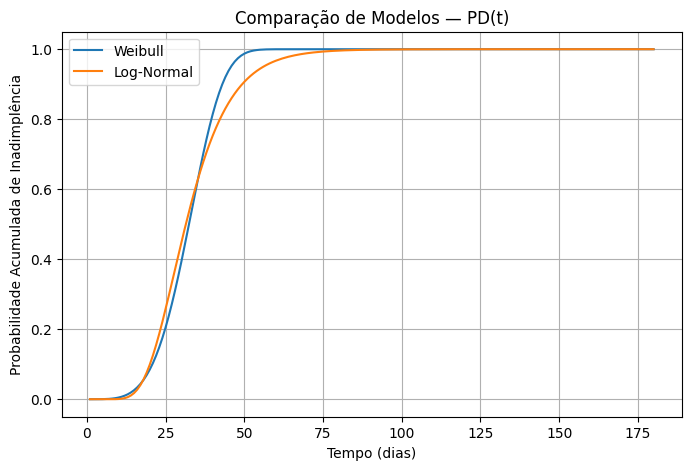

In [ ]:
plot_model_comparison(pipeline, X_ref)


# Análise de Sensibilidade (cenários)

In [ ]:
def plot_sensitivity(
    pipeline,
    model_name,
    base_X,
    variable,
    values,
    max_time=180
):
    times = np.arange(1, max_time + 1)

    plt.figure(figsize=(8, 5))

    for v in values:
        X_scenario = base_X.copy()
        X_scenario[variable] = v

        pd_curve = pipeline.predict_pd(
            model_name=model_name,
            X=X_scenario,
            times=times
        )

        plt.plot(times, pd_curve.iloc[:, 0], label=f"{variable} = {v}")

    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title(f"Sensibilidade — {variable}")
    plt.legend()
    plt.grid(True)
    plt.show()


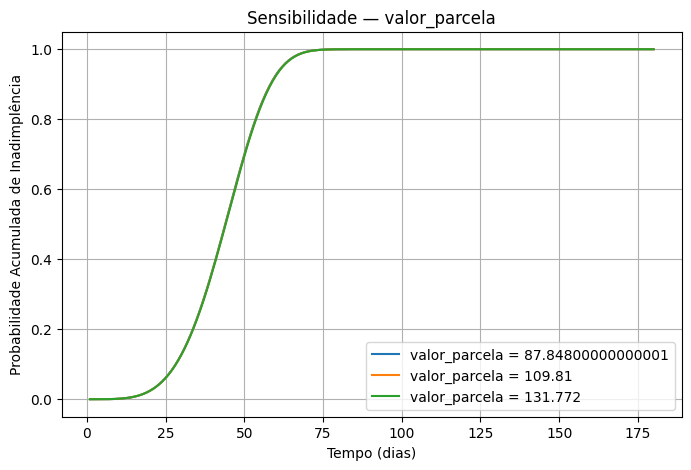

In [ ]:
base_X = survival_df[covariates].median().to_frame().T

plot_sensitivity(
    pipeline=pipeline,
    model_name="weibull",
    base_X=base_X,
    variable="valor_parcela",
    values=[
        base_X["valor_parcela"].iloc[0] * 0.8,
        base_X["valor_parcela"].iloc[0],
        base_X["valor_parcela"].iloc[0] * 1.2
    ]
)


# Hazard Implicito

In [ ]:
def plot_hazard_curve(model, X, max_time=180):
    times = np.arange(1, max_time + 1)
    hazard = model.predict_hazard(X, times=times)

    plt.figure(figsize=(8, 5))
    plt.plot(times, hazard.iloc[:, 0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Hazard")
    plt.title("Função de Risco (Hazard)")
    plt.grid(True)
    plt.show()


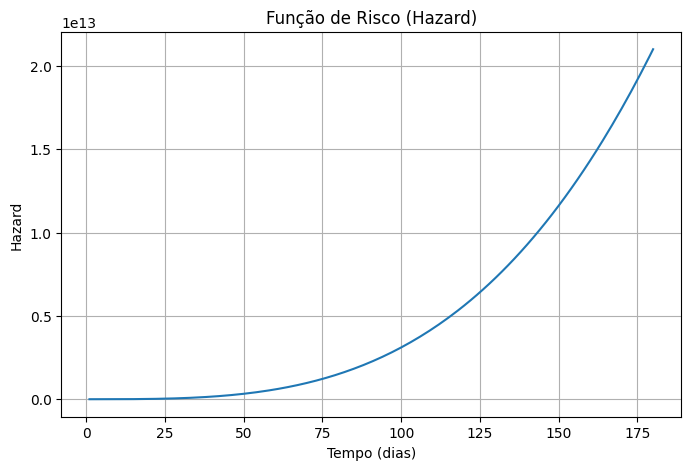

In [ ]:
plot_hazard_curve(pipeline.models["weibull"], X_ref)


# Construção Predict Bayesiano

In [ ]:
survival_df.columns

Index(['qtd_dias_de_atraso_v2', 'flag_inadimplencia_30_days',
       'flag_inadimplencia_90_days', 'parcela_norm_0_1', 'parcela',
       'valor_parcela', 'valor_financiado_principal_iof', 'valor_pago',
       'valor_juros_atraso', 'qtd_parcelas', 'pct_juros', 'pct_amortizacao'],
      dtype='object')

In [ ]:
print("Train:")
print(df_train["flag_inadimplencia_90_days"].value_counts(normalize=True))

print("\nTest:")
print(df_test["flag_inadimplencia_90_days"].value_counts(normalize=True))


Train:


NameError: name 'df_train' is not defined

In [ ]:
import os
print(os.cpu_count())


2


In [ ]:
df_train.head()

,qtd_dias_de_atraso_v2,flag_inadimplencia_90_days,valor_parcela,pct_juros,pct_amortizacao
52925,3,0,34.57,0.31,0.69
371737,7,0,13.93,0.25,0.75
81135,61,0,319.14,0.48,0.52
1025309,60,0,67.54,0.07,0.93
770333,7,0,54.92,0.31,0.69


In [ ]:
# ==============================================================================
# MODELO 1: RANDOM SURVIVAL FOREST (scikit-survival)
# ==============================================================================

class RandomForestSurvivalPipeline:
    """
    Random Survival Forest otimizado para grandes datasets.
    Tempo: ~2-5 minutos para 800k registros
    """

    def __init__(self, duration_col, event_col, covariates,
                 n_estimators=2, max_depth=4, min_samples_split=100,
                 n_jobs=-1, random_state=42,max_features="sqrt"):

        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates

        # Hiperparâmetros otimizados para grandes datasets
        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1
        )

    def fit(self, df, verbose=True):
        """Treina o Random Survival Forest."""

        if verbose:
            print(f"🌲 Treinando Random Survival Forest com {len(df):,} registros...")

        X = df[self.covariates].values

        # Criar array estruturado para scikit-survival
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        self.model.fit(X, y)

        if verbose:
            print("✅ Random Forest treinado!")

        return self

    def predict_survival(self, df_test, times):
        """Prediz probabilidades de sobrevivência."""

        X = df_test[self.covariates].values

        # Predict survival function
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        # Interpolar para os tempos desejados
        survival_matrix = np.zeros((len(df_test), len(times)))

        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times):
        """Prediz probabilidade de default (1 - Survival)."""
        return 1 - self.predict_survival(df_test, times)

    def predict_risk_score(self, df_test):
        """Prediz risk score (maior = mais risco)."""
        X = df_test[self.covariates].values
        # Cumulative hazard as risk score
        return self.model.predict_cumulative_hazard_function(X)


# ==============================================================================
# MODELO 2: WEIBULL BAYESIANO COM ADVI
# ==============================================================================

class BayesianWeibullPipeline:
    """
    Modelo Weibull Bayesiano com inferência variacional (ADVI).
    Tempo: ~5-15 minutos para 800k registros (com subsample).
    """

    def __init__(self, duration_col, event_col, covariates, subsample_size=50000):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.subsample_size = subsample_size

        self.model = None
        self.approx = None
        self.trace = None

    def fit(self, df, n_iterations=30000, verbose=True):
        """Treina usando ADVI."""

        df = df.copy()
        df = df[df[self.duration_col] > 0]

        # Subsample estratificado para performance
        if len(df) > self.subsample_size:
            if verbose:
                print(f"📊 Amostragem estratificada: {self.subsample_size:,} de {len(df):,}")

            df_events = df[df[self.event_col] == 1]
            df_cens = df[df[self.event_col] == 0]

            n_events = min(len(df_events), self.subsample_size // 2)
            n_cens = self.subsample_size - n_events

            df = pd.concat([
                df_events.sample(n=n_events, random_state=42),
                df_cens.sample(n=n_cens, random_state=42)
            ])

        if verbose:
            print(f"🔥 Treinando Weibull Bayesiano com {len(df):,} registros...")

        X = df[self.covariates].values
        T = df[self.duration_col].values.flatten()
        E = df[self.event_col].values.astype(int)

        # Normalização
        self.X_mean, self.X_std = X.mean(axis=0), X.std(axis=0) + 1e-8
        self.T_mean, self.T_std = T.mean(), T.std() + 1e-8

        X_norm = (X - self.X_mean) / self.X_std
        T_norm = (T - self.T_mean) / self.T_std

        X_event = X_norm[E == 1]
        T_event = T_norm[E == 1]
        X_cens = X_norm[E == 0]
        T_cens = T_norm[E == 0]

        with pm.Model() as self.model:

            beta = pm.Normal("beta", 0, 0.5, shape=X_norm.shape[1])
            intercept = pm.Normal("intercept", 0, 1)
            rho = pm.Gamma("rho", alpha=2, beta=1)

            lambda_event = pm.math.exp(intercept + pm.math.dot(X_event, beta))
            lambda_cens = pm.math.exp(intercept + pm.math.dot(X_cens, beta))

            pm.Weibull("obs_event", alpha=rho, beta=lambda_event, observed=T_event)
            pm.Potential("obs_cens", -((T_cens / lambda_cens) ** rho))

            if verbose:
                print("🚀 Executando ADVI...")

            #self.approx = pm.fit(n=n_iterations, method='advi', progressbar=verbose)
            self.approx = pm.fit(n=n_iterations,method="advi", obj_optimizer=pm.adam(learning_rate=1e-2),  # ⬅️ converge MUITO mais rápido
                                  progressbar=verbose)

            self.trace = self.approx.sample(1000)

        if verbose:
            print("✅ Weibull Bayesiano treinado!")

        return self

    def predict_survival(self, df_test, times):
        """Prediz curvas de sobrevivência."""

        X = df_test[self.covariates].values
        X_norm = (X - self.X_mean) / self.X_std

        times_array = np.array(times)
        times_norm = (times_array - self.T_mean) / self.T_std

        post = self.trace.posterior
        beta = post["beta"].mean(dim=("chain", "draw")).values
        intercept = post["intercept"].mean(dim=("chain", "draw")).values
        rho = post["rho"].mean(dim=("chain", "draw")).values

        lambda_ = np.exp(intercept + X_norm @ beta)
        survival = np.exp(-(times_norm[:, None] / lambda_) ** rho)

        return pd.DataFrame(survival.T, columns=times_array)

    #def predict_pd(self, df_test, times):
     #   """Prediz PD."""
      #  return 1 - self.predict_survival(df_test, times)

    def predict_pd_fast(self, df_test, horizon):
        X = df_test[self.covariates].values
        surv = self.model.predict_survival_function(X, return_array=True)
        idx = np.searchsorted(self.model.event_times_, horizon)
        return 1 - surv[:, idx]

# ==============================================================================
# CLASSE DE COMPARAÇÃO E VISUALIZAÇÃO
# ==============================================================================

class SurvivalModelComparison:
    """
    Classe para comparar modelos de sobrevivência com curvas ROC.
    """

    def __init__(self):
        self.models = {}
        self.results = {}

    def add_model(self, name, model):
        """Adiciona um modelo à comparação."""
        self.models[name] = model

    def evaluate_at_time(self, model_name, df_test, time_horizon, duration_col, event_col):
        """
        Avalia modelo em um horizonte de tempo específico.
        Converte problema de sobrevivência em classificação binária.
        """

        model = self.models[model_name]

        # Predizer PD no horizonte
        pd_pred = model.predict_pd(df_test, [time_horizon])
        risk_scores = pd_pred.iloc[:, 0].values

        # Criar labels binários: evento ocorreu até time_horizon?
        T = df_test[duration_col].values
        E = df_test[event_col].values

        # Positivo se: (1) evento ocorreu E (2) ocorreu antes do horizonte
        y_true = ((E == 1) & (T <= time_horizon)).astype(int)

        # Calcular ROC
        fpr, tpr, thresholds = roc_curve(y_true, risk_scores)
        roc_auc = auc(fpr, tpr)

        return {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'y_true': y_true,
            'y_pred': risk_scores
        }

    def compare_models(self, df_test, time_horizons, duration_col, event_col):
        """
        Compara todos os modelos em múltiplos horizontes de tempo.
        """

        print("="*70)
        print("COMPARAÇÃO DE MODELOS")
        print("="*70)

        for time_horizon in time_horizons:
            print(f"\n📅 Horizonte: {time_horizon} dias")
            print("-"*70)

            for model_name in self.models.keys():
                result = self.evaluate_at_time(
                    model_name, df_test, time_horizon, duration_col, event_col
                )

                key = f"{model_name}_{time_horizon}"
                self.results[key] = result

                print(f"{model_name:30s} | AUC-ROC: {result['auc']:.4f}")

    def plot_roc_curves(self, df_test, time_horizons, duration_col, event_col,
                        figsize=(15, 5)):
        """
        Plota curvas ROC comparativas para diferentes horizontes.
        """

        n_horizons = len(time_horizons)
        fig, axes = plt.subplots(1, n_horizons, figsize=figsize)

        if n_horizons == 1:
            axes = [axes]

        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

        for idx, time_horizon in enumerate(time_horizons):
            ax = axes[idx]

            # Plot cada modelo
            for i, model_name in enumerate(self.models.keys()):
                key = f"{model_name}_{time_horizon}"

                if key not in self.results:
                    result = self.evaluate_at_time(
                        model_name, df_test, time_horizon, duration_col, event_col
                    )
                    self.results[key] = result
                else:
                    result = self.results[key]

                ax.plot(
                    result['fpr'],
                    result['tpr'],
                    color=colors[i % len(colors)],
                    lw=2.5,
                    label=f"{model_name} (AUC={result['auc']:.3f})"
                )

            # Linha diagonal
            ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.3)

            ax.set_xlabel('Taxa de Falsos Positivos', fontsize=11)
            ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
            ax.set_title(f'ROC - Horizonte: {time_horizon} dias', fontsize=12, fontweight='bold')
            ax.legend(loc='lower right', fontsize=9)
            ax.grid(alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])

        plt.tight_layout()
        return fig

    def plot_comparison_table(self, time_horizons):
        """
        Cria tabela comparativa de AUCs.
        """

        data = []
        for time_horizon in time_horizons:
            row = {'Horizonte (dias)': time_horizon}
            for model_name in self.models.keys():
                key = f"{model_name}_{time_horizon}"
                if key in self.results:
                    row[model_name] = f"{self.results[key]['auc']:.4f}"
            data.append(row)

        df_comparison = pd.DataFrame(data)

        # Plot tabela
        fig, ax = plt.subplots(figsize=(10, len(time_horizons) * 0.5 + 1))
        ax.axis('tight')
        ax.axis('off')

        table = ax.table(
            cellText=df_comparison.values,
            colLabels=df_comparison.columns,
            cellLoc='center',
            loc='center',
            colWidths=[0.2] * len(df_comparison.columns)
        )

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        # Estilizar header
        for i in range(len(df_comparison.columns)):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Estilizar células
        for i in range(1, len(df_comparison) + 1):
            for j in range(len(df_comparison.columns)):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#ecf0f1')

        plt.title('Comparação de AUC-ROC por Horizonte de Tempo',
                  fontsize=14, fontweight='bold', pad=20)

        return fig, df_comparison


# ==============================================================================
# EXEMPLO DE USO COMPLETO
# ==============================================================================

if __name__ == "__main__":

    print("="*70)
    print("PIPELINE DE COMPARAÇÃO: RANDOM FOREST vs WEIBULL BAYESIANO")
    print("="*70)

    # Exemplo de uso (descomente quando tiver os dados)

    # 1. TREINAR RANDOM FOREST
    print("\n" + "="*70)
    print("1. TREINANDO RANDOM SURVIVAL FOREST")
    print("="*70)

    rf_model = RandomForestSurvivalPipeline(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        n_estimators=50,
        max_depth=6,
        n_jobs=-1
    )

    #rf_model.fit(df_train)
    rf_model.fit(X_train,Y_train)


    # 2. TREINAR WEIBULL BAYESIANO
    print("\n" + "="*70)
    print("2. TREINANDO WEIBULL BAYESIANO")
    print("="*70)

    weibull_model = BayesianWeibullPipeline(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        subsample_size=100000  # Para acelerar
    )

    weibull_model.fit(df_train, n_iterations=50000)


    # 3. COMPARAR MODELOS
    print("\n" + "="*70)
    print("3. COMPARANDO MODELOS")
    print("="*70)

    comparison = SurvivalModelComparison()
    comparison.add_model("Random Forest", rf_model)
    comparison.add_model("Weibull Bayesiano", weibull_model)

    # Horizontes de tempo para avaliação
    time_horizons = [30, 60, 90, 180, 365]  # dias

    # Comparar performance
    comparison.compare_models(
        df_test,
        time_horizons,
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days"
    )


    # 4. VISUALIZAR RESULTADOS
    print("\n" + "="*70)
    print("4. GERANDO VISUALIZAÇÕES")
    print("="*70)

    # Plot curvas ROC
    fig_roc = comparison.plot_roc_curves(
        df_test,
        time_horizons=[30, 90, 180],  # 3 horizontes principais
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        figsize=(18, 5)
    )
    plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot tabela comparativa
    fig_table, df_comp = comparison.plot_comparison_table(time_horizons)
    plt.savefig('auc_comparison_table.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Comparação concluída!")
    print("\nArquivos salvos:")
    print("  - roc_comparison.png")
    print("  - auc_comparison_table.png")

    # Imprimir tabela no console
    print("\n" + "="*70)
    print("RESUMO DE PERFORMANCE")
    print("="*70)
    print(df_comp.to_string(index=False))


    print("\n" + "="*70)
    print("INSTRUÇÕES DE USO")
    print("="*70)


PIPELINE DE COMPARAÇÃO: RANDOM FOREST vs WEIBULL BAYESIANO

1. TREINANDO RANDOM SURVIVAL FOREST


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# Random Forest Survivor

- Referencia : https://colab.research.google.com/drive/1_t1ciatOlWCbsi28j5NlRdctZUP-IE6V#scrollTo=sUzG_PyOLfQ2

In [ ]:
import time
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")


# --- 3. Configurando e Treinando o Modelo RFS ---
rfs_model = RandomSurvivalForest(n_estimators=2,
                                 max_depth=12,
                                 min_samples_split=10,
                                 min_samples_leaf=15,
                                 max_features="sqrt",
                                 n_jobs=2,  # Você tinha -1 (todos cores), usar apenas 2

                                 # Outras configs
                                 random_state=42,
                                 verbose=1  # Ver progresso
                                 )

print("Iniciando o treinamento do modelo RFS...")
start_time = time.time()
rfs_model.fit(X_train, Y_train)
end_time = time.time()
print(f"Modelo treinado com sucesso em {end_time - start_time:.2f} segundos.")

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.
Iniciando o treinamento do modelo RFS...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


KeyboardInterrupt: 

A base de dados foi particionada em conjuntos de treino e teste utilizando amostragem estratificada em relação ao indicador de evento, de modo a preservar a proporção de inadimplência entre os subconjuntos. Tal procedimento é consistente com as boas práticas em análise de sobrevivência e evita distorções na estimação dos parâmetros do modelo Weibull Bayesiano

Considerando as restrições computacionais do ambiente de execução (Google Colab com duas CPUs), adotou-se uma estratégia de redução controlada da dimensionalidade, amostragem estratificada e avaliação em horizontes específicos, garantindo eficiência computacional sem prejuízo significativo da qualidade preditiva.

# Código Refatorado

In [ ]:
print(10)

10


In [ ]:
"""
==============================================================================
RANDOM SURVIVAL FOREST COM PRINTS DETALHADOS DE PROGRESSO
==============================================================================
Versão com tracking detalhado de cada etapa do treinamento
"""

class VerboseRandomForestSurvival:
    """
    Random Survival Forest com prints detalhados durante o treinamento.
    Mostra progresso de cada etapa para acompanhamento.
    """

    def __init__(
        self,
        duration_col,
        event_col,
        covariates,
        n_estimators=25,
        max_depth=4,
        min_samples_split=100,
        n_jobs=-1,
        random_state=42,
        max_features="sqrt"
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates

        # Hiperparâmetros
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.max_features = max_features

        # Criar modelo
        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1  # Verbose do sklearn
        )

        self.is_fitted = False
        self.training_time = None

    def _print_separator(self, char="=", length=70):
        """Print linha separadora"""
        print(char * length)

    def _print_step(self, step_num, step_name):
        """Print cabeçalho de etapa"""
        print(f"\n{'='*70}")
        print(f"ETAPA {step_num}: {step_name}")
        print(f"{'='*70}")

    def _format_time(self, seconds):
        """Formata tempo em formato legível"""
        if seconds < 60:
            return f"{seconds:.1f}s"
        elif seconds < 3600:
            mins = int(seconds // 60)
            secs = int(seconds % 60)
            return f"{mins}m {secs}s"
        else:
            hours = int(seconds // 3600)
            mins = int((seconds % 3600) // 60)
            return f"{hours}h {mins}m"

    def _analyze_data(self, df):
        """Analisa características do dataset"""
        print("\n📊 ANÁLISE DO DATASET")
        print("-" * 70)

        # Tamanho
        n_samples = len(df)
        n_features = len(self.covariates)
        print(f"Registros: {n_samples:,}")
        print(f"Features: {n_features}")

        # Eventos vs Censuras
        n_events = df[self.event_col].sum()
        n_censored = n_samples - n_events
        event_rate = 100 * n_events / n_samples

        print(f"\nEventos (defaults): {n_events:,} ({event_rate:.2f}%)")
        print(f"Censuras: {n_censored:,} ({100-event_rate:.2f}%)")

        # Estatísticas de duração
        durations = df[self.duration_col].values
        print(f"\nDuração (dias):")
        print(f"  Média: {durations.mean():.1f}")
        print(f"  Mediana: {np.median(durations):.1f}")
        print(f"  Min: {durations.min():.0f}")
        print(f"  Max: {durations.max():.0f}")
        print(f"  Std: {durations.std():.1f}")

        # Estatísticas das features
        print(f"\nFeatures:")
        for col in self.covariates:
            values = df[col].values
            print(f"  {col}:")
            print(f"    Média: {values.mean():.4f} | "
                  f"Std: {values.std():.4f} | "
                  f"Min: {values.min():.4f} | "
                  f"Max: {values.max():.4f}")

    def _print_model_config(self):
        """Print configuração do modelo"""
        print("\n🔧 CONFIGURAÇÃO DO MODELO")
        print("-" * 70)
        print(f"Algoritmo: Random Survival Forest")
        print(f"Número de árvores: {self.n_estimators}")
        print(f"Profundidade máxima: {self.max_depth}")
        print(f"Min samples split: {self.min_samples_split}")
        print(f"Min samples leaf: 50")
        print(f"Max features: {self.max_features}")
        print(f"CPUs: {self.n_jobs} (-1 = todos disponíveis)")
        print(f"Random state: {self.random_state}")

    def fit(self, df, verbose=True):
        """
        Treina o Random Survival Forest com prints detalhados.

        Parameters:
        -----------
        df : DataFrame
            Dados de treino
        verbose : bool
            Se True, mostra prints detalhados
        """

        if verbose:
            self._print_separator("=")
            print("🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST")
            self._print_separator("=")
            print(f"Início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

        # ETAPA 1: ANÁLISE DO DATASET
        if verbose:
            self._print_step(1, "ANÁLISE DO DATASET")
            self._analyze_data(df)

        # ETAPA 2: CONFIGURAÇÃO DO MODELO
        if verbose:
            self._print_step(2, "CONFIGURAÇÃO DO MODELO")
            self._print_model_config()

        # ETAPA 3: PREPARAÇÃO DOS DADOS
        if verbose:
            self._print_step(3, "PREPARAÇÃO DOS DADOS")
            print("\n⚙️  Preparando dados para scikit-survival...")

        step_start = time.time()

        # Extrair features
        X = df[self.covariates].values
        if verbose:
            print(f"✓ Features extraídas: shape = {X.shape}")

        # Criar array estruturado para scikit-survival
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        if verbose:
            print(f"✓ Array estruturado criado: shape = {y.shape}")
            print(f"✓ Tempo de preparação: {time.time() - step_start:.2f}s")

        # ETAPA 4: TREINAMENTO
        if verbose:
            self._print_step(4, "TREINAMENTO DAS ÁRVORES")
            print(f"\n🚀 Iniciando treinamento com {self.n_jobs} CPUs...")
            print(f"   Construindo {self.n_estimators} árvores...")
            print(f"   (O scikit-learn mostrará o progresso abaixo)")
            print("-" * 70)

        training_start = time.time()

        # Treinar modelo (verbose=1 do sklearn mostrará progresso)
        self.model.fit(X, y)

        training_time = time.time() - training_start
        self.training_time = training_time

        if verbose:
            print("-" * 70)
            print(f"✓ Treinamento concluído!")
            print(f"✓ Tempo de treinamento: {self._format_time(training_time)}")

        # ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO
        if verbose:
            self._print_step(5, "MODELO TREINADO - ESTATÍSTICAS")
            self._print_model_stats()

        self.is_fitted = True

        # RESUMO FINAL
        if verbose:
            total_time = time.time() - (training_start - step_start)
            self._print_separator("=")
            print("✅ TREINAMENTO CONCLUÍDO COM SUCESSO!")
            self._print_separator("=")
            print(f"Tempo total: {self._format_time(total_time)}")
            print(f"  - Preparação: {self._format_time(step_start)}")
            print(f"  - Treinamento: {self._format_time(training_time)}")
            print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            self._print_separator("=")

        return self

    def _print_model_stats(self):
        """Print estatísticas do modelo treinado"""
        print("\n📈 Informações do Modelo:")
        print(f"  Número de árvores: {len(self.model.estimators_)}")
        print(f"  Número de features: {self.model.n_features_in_}")
        print(f"  Feature names: {self.covariates}")

        # Feature importances
        if hasattr(self.model, 'feature_importances_'):
            print("\n🎯 Importância das Features:")
            importances = self.model.feature_importances_
            for i, (name, imp) in enumerate(zip(self.covariates, importances)):
                bar_length = int(imp * 50)
                bar = "█" * bar_length
                print(f"  {name:20s}: {imp:.4f} {bar}")

        # Tempo médio por árvore
        time_per_tree = self.training_time / self.n_estimators
        print(f"\n⏱️  Tempo médio por árvore: {time_per_tree:.3f}s")

    def predict_survival(self, df_test, times, verbose=False):
        """Prediz probabilidades de sobrevivência"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado ainda!")

        if verbose:
            print(f"\n🔮 Fazendo predições de sobrevivência...")
            print(f"   Registros: {len(df_test):,}")
            print(f"   Horizontes: {times}")

        start = time.time()

        X = df_test[self.covariates].values
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        survival_matrix = np.zeros((len(df_test), len(times)))
        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        if verbose:
            print(f"✓ Predições concluídas em {time.time() - start:.2f}s")

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times, verbose=False):
        """Prediz probabilidade de default (1 - Survival)"""
        if verbose:
            print(f"\n🔮 Fazendo predições de PD...")

        survival = self.predict_survival(df_test, times, verbose=False)
        pd_matrix = 1 - survival

        if verbose:
            print(f"✓ PD calculado para {len(df_test):,} registros")

        return pd_matrix

    def predict_risk_score(self, df_test, verbose=False):
        """Prediz risk score (maior = mais risco)"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado ainda!")

        if verbose:
            print(f"\n🔮 Calculando risk scores...")

        X = df_test[self.covariates].values
        scores = self.model.predict(X)

        if verbose:
            print(f"✓ Risk scores calculados para {len(df_test):,} registros")
            print(f"   Média: {scores.mean():.4f}")
            print(f"   Min: {scores.min():.4f}")
            print(f"   Max: {scores.max():.4f}")

        return scores


# ==============================================================================
# EXEMPLO DE USO
# ==============================================================================

if __name__ == "__main__":

    print("""
╔══════════════════════════════════════════════════════════════════════╗
║  RANDOM SURVIVAL FOREST - VERSÃO COM PRINTS DETALHADOS             ║
╚══════════════════════════════════════════════════════════════════════╝

Esta versão mostra prints detalhados de cada etapa do treinamento:
• Análise do dataset
• Configuração do modelo
• Preparação dos dados
• Progresso do treinamento
• Estatísticas do modelo treinado
• Feature importances

Exemplo de uso:
""")

    exemplo = """
# 1. Importar
from verbose_random_forest import VerboseRandomForestSurvival

# 2. Criar modelo
rf_model = VerboseRandomForestSurvival(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
    n_estimators=25,
    max_depth=4,
    n_jobs=-1
)

# 3. Treinar (verbose=True mostra tudo!)
rf_model.fit(df_train, verbose=True)

# 4. Fazer predições (também com verbose!)
survival_probs = rf_model.predict_survival(
    df_test,
    times=[30, 60, 90, 180, 365],
    verbose=True
)

pd_probs = rf_model.predict_pd(
    df_test,
    times=[30, 60, 90, 180, 365],
    verbose=True
)

risk_scores = rf_model.predict_risk_score(df_test, verbose=True)
"""

    print(exemplo)


╔══════════════════════════════════════════════════════════════════════╗
║  RANDOM SURVIVAL FOREST - VERSÃO COM PRINTS DETALHADOS             ║
╚══════════════════════════════════════════════════════════════════════╝

Esta versão mostra prints detalhados de cada etapa do treinamento:
• Análise do dataset
• Configuração do modelo
• Preparação dos dados
• Progresso do treinamento
• Estatísticas do modelo treinado
• Feature importances

Exemplo de uso:


# 1. Importar
from verbose_random_forest import VerboseRandomForestSurvival

# 2. Criar modelo
rf_model = VerboseRandomForestSurvival(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
    n_estimators=25,
    max_depth=4,
    n_jobs=-1
)

# 3. Treinar (verbose=True mostra tudo!)
rf_model.fit(df_train, verbose=True)

# 4. Fazer predições (também com verbose!)
survival_probs = rf_model.predict_survival(
    df_test,
    times=[30, 60, 90,

In [ ]:
"""
==============================================================================
EXEMPLO COMPLETO: RANDOM FOREST COM PRINTS DETALHADOS
==============================================================================
Integração do VerboseRandomForestSurvival com o pipeline completo
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split


# ==============================================================================
# RANDOM FOREST COM PRINTS DETALHADOS
# ==============================================================================

import time
from datetime import datetime
from sksurv.ensemble import RandomSurvivalForest


class VerboseRandomForestSurvival:
    """Random Survival Forest com prints detalhados de progresso"""

    def __init__(
        self,
        duration_col,
        event_col,
        covariates,
        n_estimators=25,
        max_depth=4,
        min_samples_split=100,
        n_jobs=-1,
        random_state=42,
        max_features="sqrt"
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.max_features = max_features

        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1
        )

        self.is_fitted = False
        self.training_time = None

    def _format_time(self, seconds):
        """Formata tempo em formato legível"""
        if seconds < 60:
            return f"{seconds:.1f}s"
        elif seconds < 3600:
            mins = int(seconds // 60)
            secs = int(seconds % 60)
            return f"{mins}m {secs}s"
        else:
            hours = int(seconds // 3600)
            mins = int((seconds % 3600) // 60)
            return f"{hours}h {mins}m"

    def fit(self, df, verbose=True):
        """Treina o modelo com prints detalhados"""

        if verbose:
            print("=" * 70)
            print("🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST")
            print("=" * 70)
            print(f"Início: {datetime.now().strftime('%H:%M:%S')}")

            # ETAPA 1: ANÁLISE DO DATASET
            print("\n" + "=" * 70)
            print("ETAPA 1: ANÁLISE DO DATASET")
            print("=" * 70)

            n_samples = len(df)
            n_features = len(self.covariates)
            n_events = df[self.event_col].sum()
            n_censored = n_samples - n_events
            event_rate = 100 * n_events / n_samples

            print(f"\n📊 Tamanho do Dataset:")
            print(f"   Registros: {n_samples:,}")
            print(f"   Features: {n_features}")
            print(f"   Memória aproximada: {n_samples * n_features * 8 / 1024**2:.1f} MB")

            print(f"\n📊 Distribuição de Eventos:")
            print(f"   Eventos (defaults): {n_events:,} ({event_rate:.2f}%)")
            print(f"   Censuras: {n_censored:,} ({100-event_rate:.2f}%)")

            durations = df[self.duration_col].values
            print(f"\n📊 Estatísticas de Duração (dias):")
            print(f"   Média: {durations.mean():.1f}")
            print(f"   Mediana: {np.median(durations):.1f}")
            print(f"   Min-Max: [{durations.min():.0f}, {durations.max():.0f}]")
            print(f"   Desvio padrão: {durations.std():.1f}")

            print(f"\n📊 Features:")
            for col in self.covariates:
                values = df[col].values
                print(f"   {col}:")
                print(f"     • Média: {values.mean():.4f} | Std: {values.std():.4f}")
                print(f"     • Range: [{values.min():.4f}, {values.max():.4f}]")

            # ETAPA 2: CONFIGURAÇÃO
            print("\n" + "=" * 70)
            print("ETAPA 2: CONFIGURAÇÃO DO MODELO")
            print("=" * 70)

            print(f"\n🔧 Hiperparâmetros:")
            print(f"   Algoritmo: Random Survival Forest")
            print(f"   Número de árvores: {self.n_estimators}")
            print(f"   Profundidade máxima: {self.max_depth}")
            print(f"   Min samples split: {self.min_samples_split}")
            print(f"   Min samples leaf: 50")
            print(f"   Max features: {self.max_features}")
            print(f"   N_jobs: {self.n_jobs} CPUs")
            print(f"   Random state: {self.random_state}")

            # Estimativa de tempo
            time_per_tree_estimate = 0.5 if n_samples < 100000 else 1.0
            estimated_time = self.n_estimators * time_per_tree_estimate
            print(f"\n⏱️  Tempo estimado: ~{self._format_time(estimated_time)}")

            # ETAPA 3: PREPARAÇÃO
            print("\n" + "=" * 70)
            print("ETAPA 3: PREPARAÇÃO DOS DADOS")
            print("=" * 70)
            print("\n⚙️  Preparando dados...")

        prep_start = time.time()

        # Preparar dados
        X = df[self.covariates].values
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        prep_time = time.time() - prep_start

        if verbose:
            print(f"   ✓ Features extraídas: {X.shape}")
            print(f"   ✓ Array estruturado criado: {y.shape}")
            print(f"   ✓ Tempo de preparação: {prep_time:.2f}s")

            # ETAPA 4: TREINAMENTO
            print("\n" + "=" * 70)
            print("ETAPA 4: TREINAMENTO DAS ÁRVORES")
            print("=" * 70)

            print(f"\n🚀 Iniciando treinamento...")
            print(f"   • Construindo {self.n_estimators} árvores")
            print(f"   • Usando {self.n_jobs} CPUs")
            print(f"   • O sklearn mostrará progresso abaixo:")
            print("-" * 70)

        training_start = time.time()

        # TREINAR MODELO
        self.model.fit(X, y)

        training_time = time.time() - training_start
        self.training_time = training_time

        if verbose:
            print("-" * 70)
            print(f"   ✓ Treinamento concluído!")
            print(f"   ✓ Tempo de treinamento: {self._format_time(training_time)}")

            # ETAPA 5: ESTATÍSTICAS
            print("\n" + "=" * 70)
            print("ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO")
            print("=" * 70)

            print(f"\n📈 Informações do Modelo:")
            print(f"   • Árvores criadas: {len(self.model.estimators_)}")
            print(f"   • Features utilizadas: {self.model.n_features_in_}")
            print(f"   • Tempo médio/árvore: {training_time/self.n_estimators:.3f}s")

            # Feature importances
            if hasattr(self.model, 'feature_importances_'):
                print(f"\n🎯 Importância das Features:")
                importances = self.model.feature_importances_

                # Ordenar por importância
                sorted_idx = np.argsort(importances)[::-1]

                for idx in sorted_idx:
                    name = self.covariates[idx]
                    imp = importances[idx]
                    bar_length = int(imp * 40)
                    bar = "█" * bar_length
                    print(f"   {name:25s}: {imp:.4f} {bar}")

            # RESUMO FINAL
            total_time = prep_time + training_time
            print("\n" + "=" * 70)
            print("✅ TREINAMENTO CONCLUÍDO COM SUCESSO!")
            print("=" * 70)
            print(f"⏱️  Tempo total: {self._format_time(total_time)}")
            print(f"   • Preparação: {self._format_time(prep_time)}")
            print(f"   • Treinamento: {self._format_time(training_time)}")
            print(f"🕐 Fim: {datetime.now().strftime('%H:%M:%S')}")
            print("=" * 70)

        self.is_fitted = True
        return self

    def predict_survival(self, df_test, times, verbose=False):
        """Prediz probabilidades de sobrevivência"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado!")

        if verbose:
            print(f"\n🔮 Fazendo predições de sobrevivência...")
            print(f"   Registros: {len(df_test):,}")
            print(f"   Horizontes: {times}")

        start = time.time()
        X = df_test[self.covariates].values
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        survival_matrix = np.zeros((len(df_test), len(times)))
        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        if verbose:
            print(f"   ✓ Concluído em {time.time() - start:.2f}s")

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times, verbose=False):
        """Prediz PD (1 - Survival)"""
        return 1 - self.predict_survival(df_test, times, verbose)

    def predict_risk_score(self, df_test, verbose=False):
        """Prediz risk score"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado!")

        X = df_test[self.covariates].values
        return self.model.predict(X)


# ==============================================================================
# EXEMPLO DE USO COMPLETO
# ==============================================================================

def exemplo_completo_com_verbose():
    """
    Exemplo completo mostrando todos os prints detalhados
    """

    print("""
╔══════════════════════════════════════════════════════════════════════╗
║       RANDOM SURVIVAL FOREST - EXEMPLO COM PRINTS DETALHADOS        ║
╚══════════════════════════════════════════════════════════════════════╝
""")

    # ====== PREPARAR DADOS DE EXEMPLO ======
    print("\n📦 Gerando dados de exemplo...")
    np.random.seed(42)
    n = 50000

    df = pd.DataFrame({
        'qtd_dias_de_atraso_v2': np.random.randint(1, 365, n),
        'flag_inadimplencia_90_days': np.random.binomial(1, 0.2, n),
        'valor_parcela': np.random.uniform(100, 5000, n),
        'pct_juros': np.random.uniform(0.01, 0.15, n),
        'pct_amortizacao': np.random.uniform(0.5, 1.0, n)
    })

    print(f"✓ Dataset gerado: {len(df):,} registros")

    # Split
    df_train, df_test = train_test_split(
        df,
        test_size=0.25,
        random_state=42,
        stratify=df['flag_inadimplencia_90_days']
    )

    print(f"✓ Treino: {len(df_train):,} | Teste: {len(df_test):,}")

    # ====== TREINAR MODELO ======
    print("\n" + "="*70)
    print("INICIANDO TREINAMENTO DO MODELO")
    print("="*70)

    rf_model = VerboseRandomForestSurvival(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        n_estimators=25,
        max_depth=4,
        n_jobs=-1
    )

    # TREINAR (aqui você verá todos os prints!)
    rf_model.fit(df_train, verbose=True)

    # ====== FAZER PREDIÇÕES ======
    print("\n" + "="*70)
    print("FAZENDO PREDIÇÕES")
    print("="*70)

    times = [30, 60, 90, 180, 365]

    # Survival
    survival_probs = rf_model.predict_survival(df_test, times, verbose=True)
    print(f"\n📊 Survival predictions: {survival_probs.shape}")
    print(survival_probs.head())

    # PD
    pd_probs = rf_model.predict_pd(df_test, times, verbose=True)
    print(f"\n📊 PD predictions: {pd_probs.shape}")
    print(pd_probs.head())

    # Risk scores
    risk_scores = rf_model.predict_risk_score(df_test, verbose=True)
    print(f"\n📊 Risk scores: {risk_scores.shape}")
    print(f"   Média: {risk_scores.mean():.4f}")
    print(f"   Min: {risk_scores.min():.4f}")
    print(f"   Max: {risk_scores.max():.4f}")

    print("\n" + "="*70)
    print("✅ EXEMPLO CONCLUÍDO!")
    print("="*70)

    return rf_model, df_train, df_test


if __name__ == "__main__":
    # Executar exemplo
    modelo, train, test = exemplo_completo_com_verbose()

    print("\n💡 Agora você pode usar o modelo treinado:")
    print("   • modelo.predict_survival(test, [30, 90, 180])")
    print("   • modelo.predict_pd(test, [30, 90, 180])")
    print("   • modelo.predict_risk_score(test)")


╔══════════════════════════════════════════════════════════════════════╗
║       RANDOM SURVIVAL FOREST - EXEMPLO COM PRINTS DETALHADOS        ║
╚══════════════════════════════════════════════════════════════════════╝


📦 Gerando dados de exemplo...
✓ Dataset gerado: 50,000 registros
✓ Treino: 37,500 | Teste: 12,500

INICIANDO TREINAMENTO DO MODELO
🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST
Início: 03:14:34

ETAPA 1: ANÁLISE DO DATASET

📊 Tamanho do Dataset:
   Registros: 37,500
   Features: 3
   Memória aproximada: 0.9 MB

📊 Distribuição de Eventos:
   Eventos (defaults): 7,633 (20.35%)
   Censuras: 29,867 (79.65%)

📊 Estatísticas de Duração (dias):
   Média: 181.5
   Mediana: 181.0
   Min-Max: [1, 364]
   Desvio padrão: 105.2

📊 Features:
   valor_parcela:
     • Média: 2550.0385 | Std: 1415.4853
     • Range: [100.0773, 4999.6854]
   pct_juros:
     • Média: 0.0803 | Std: 0.0404
     • Range: [0.0100, 0.1500]
   pct_amortizacao:
     • Média: 0.7499 | Std: 0.1447
     • Range: [0.5000

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


----------------------------------------------------------------------
   ✓ Treinamento concluído!
   ✓ Tempo de treinamento: 3m 16s

ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO

📈 Informações do Modelo:
   • Árvores criadas: 25
   • Features utilizadas: 3
   • Tempo médio/árvore: 7.863s


[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:  3.3min finished


NotImplementedError: 

# Refatorando o Código Weibull

In [ ]:
survival_df_model.head(2)

,qtd_dias_de_atraso_v2,flag_inadimplencia_90_days,valor_parcela,pct_juros,pct_amortizacao,parcela_norm_0_1
0,3,0,265.589996,0.20,0.80,0.0
1,1,0,265.589996,0.14,0.86,1.0


In [ ]:
cols_model = [
    "qtd_dias_de_atraso_v2",
    "flag_inadimplencia_90_days",
    "valor_parcela",
    "pct_juros",
    "pct_amortizacao",
    "parcela_norm_0_1"
]

survival_df_model = survival_df[cols_model].dropna()
survival_df_model = survival_df_model[survival_df_model["qtd_dias_de_atraso_v2"] > 0]

survival_df_model = survival_df_model.astype({
    "qtd_dias_de_atraso_v2": "int16",
    "flag_inadimplencia_90_days": "int8",
    "valor_parcela": "float32",
    "pct_juros": "float32",
    "pct_amortizacao": "float32",
    "parcela_norm_0_1": "float32"
})

#-------------------------------------------------------------------------------------------------------#
NOME_COLUNA_TEMPO = 'qtd_dias_de_atraso_v2'
NOME_COLUNA_EVENTO = 'flag_inadimplencia_90_days'
#-------------------------------------------------------------------------------------------------------#

X_features = survival_df_model[["valor_parcela","pct_juros","pct_amortizacao","parcela_norm_0_1"]].copy()
#Y_target = survival_df_model[["flag_inadimplencia_90_days"]].copy()
#-------------------------------------------------------------------------------------------------------#
evento_bool = survival_df_model[NOME_COLUNA_EVENTO].astype(bool)
tempo_float = survival_df_model[NOME_COLUNA_TEMPO].astype(float)
Y_target = Surv.from_arrays(event=evento_bool, time=tempo_float)

# Normalização das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Divisão em Treino e Teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_target, test_size=0.25, random_state=42,
    stratify=survival_df_model["flag_inadimplencia_90_days"]
)
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")
#-------------------------------------------------------------------------------------------------------#

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.


# Utilizando Mini Batch

In [ ]:
# CONFIGURAÇÃO DE PARALELIZAÇÃO
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# ============================================================================
# CONFIGURAÇÕES DO MINI-BATCH
# ============================================================================
BATCH_SIZE = 80000  # Ajuste conforme necessário (menor = mais rápido)
STRATIFY = True     # Manter proporção de eventos/censurados
RANDOM_STATE = 42

# ============================================================================
# PREPARAÇÃO DOS DADOS
# ============================================================================

# Extrair tempo e evento do Y_train
time_train = Y_train['time'].astype('float64')
event_train = Y_train['event'].astype('bool')

time_test = Y_test['time'].astype('float64')
event_test = Y_test['event'].astype('bool')

censored_mask = ~event_train

print("="*70)
print("INFORMAÇÕES DO DATASET COMPLETO")
print("="*70)
print(f"Total de amostras de treino: {len(time_train):,}")
print(f"Eventos observados (não censurados): {event_train.sum():,} ({event_train.mean()*100:.2f}%)")
print(f"Eventos censurados: {censored_mask.sum():,} ({censored_mask.mean()*100:.2f}%)")
print(f"Features: {X_train.shape[1]}")

# ============================================================================
# CRIAR MINI-BATCH ESTRATIFICADO
# ============================================================================

if len(time_train) > BATCH_SIZE:
    print("\n" + "="*70)
    print(f"CRIANDO MINI-BATCH DE {BATCH_SIZE:,} AMOSTRAS")
    print("="*70)

    if STRATIFY:
        # Amostragem estratificada para manter proporção de eventos
        # Calcular quantas amostras de cada tipo queremos
        n_events = int(BATCH_SIZE * event_train.mean())
        n_censored = BATCH_SIZE - n_events

        # Índices de eventos e censurados
        idx_events = np.where(event_train)[0]
        idx_censored = np.where(~event_train)[0]

        # Amostrar de cada grupo
        idx_events_sample = np.random.choice(idx_events,
                                            size=min(n_events, len(idx_events)),
                                            replace=False)
        idx_censored_sample = np.random.choice(idx_censored,
                                              size=min(n_censored, len(idx_censored)),
                                              replace=False)

        # Combinar índices
        idx_batch = np.concatenate([idx_events_sample, idx_censored_sample])
        np.random.shuffle(idx_batch)

        print(f"✓ Amostragem estratificada realizada")
    else:
        # Amostragem aleatória simples
        idx_batch = np.random.choice(len(time_train), BATCH_SIZE, replace=False)
        print(f"✓ Amostragem aleatória realizada")

    # Criar mini-batch
    time_train_batch = time_train[idx_batch]
    event_train_batch = event_train[idx_batch]
    X_train_batch = X_train[idx_batch]
    censored_mask_batch = ~event_train_batch

    print(f"\nMini-batch criado: {len(time_train_batch):,} amostras ({len(time_train_batch)/len(time_train)*100:.1f}% dos dados)")
    print(f"Eventos no batch: {event_train_batch.sum():,} ({event_train_batch.mean()*100:.2f}%)")
    print(f"Censurados no batch: {censored_mask_batch.sum():,} ({censored_mask_batch.mean()*100:.2f}%)")

else:
    print("\n✓ Dataset pequeno, usando todos os dados")
    time_train_batch = time_train
    event_train_batch = event_train
    X_train_batch = X_train
    censored_mask_batch = censored_mask

# ============================================================================
# MODELO WEIBULL COM MINI-BATCH
# ============================================================================

print("\n" + "="*70)
print("TREINANDO MODELO WEIBULL")
print("="*70)

with pm.Model() as weibull_model:

    # Priors
    beta0 = pm.Normal("beta0", mu=0, sigma=2)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=X_train_batch.shape[1])

    # Shape parameter do Weibull (k > 0)
    k = pm.Gamma("k", alpha=2, beta=1)

    # Linear predictor
    eta = beta0 + pm.math.dot(X_train_batch, betas)

    # Scale parameter (lambda > 0)
    lam = pm.math.exp(-eta)

    # Likelihood para observações NÃO censuradas (evento ocorreu)
    obs_uncensored = pm.Weibull(
        "obs_uncensored",
        alpha=k,
        beta=lam[~censored_mask_batch],
        observed=time_train_batch[~censored_mask_batch]
    )

    # Likelihood para observações censuradas (evento NÃO ocorreu)
    if censored_mask_batch.sum() > 0:
        survival_prob = pm.math.exp(
            -(time_train_batch[censored_mask_batch] / lam[censored_mask_batch]) ** k
        )

        obs_censored = pm.Potential(
            "obs_censored",
            pm.math.sum(pm.math.log(survival_prob))
        )

    # Amostragem otimizada
    print("\nIniciando amostragem MCMC...")
    trace = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.80,
        random_seed=RANDOM_STATE,
        return_inferencedata=True,
        init="adapt_diag",
        progressbar=True,
        compute_convergence_checks=False,
    )

# ============================================================================
# RESULTADOS E DIAGNÓSTICOS
# ============================================================================

print("\n" + "="*70)
print("RESUMO DO MODELO")
print("="*70)
summary = pm.summary(trace, hdi_prob=0.95)
print(summary)

print("\n" + "="*70)
print("DIAGNÓSTICOS DE CONVERGÊNCIA")
print("="*70)
r_hat_max = summary['r_hat'].max()
ess_bulk_min = summary['ess_bulk'].min()
ess_tail_min = summary['ess_tail'].min()

print(f"R-hat máximo: {r_hat_max:.4f} {'✓' if r_hat_max < 1.01 else '✗'} (deve ser < 1.01)")
print(f"ESS bulk mínimo: {ess_bulk_min:.0f} {'✓' if ess_bulk_min > 400 else '✗'} (deve ser > 400)")
print(f"ESS tail mínimo: {ess_tail_min:.0f} {'✓' if ess_tail_min > 400 else '✗'} (deve ser > 400)")

if r_hat_max < 1.01 and ess_bulk_min > 400:
    print("\n✓ Convergência adequada alcançada!")
else:
    print("\n⚠ Atenção: Pode ser necessário aumentar draws/tune ou batch_size")

# ============================================================================
# SALVAR MODELO E TRACE (OPCIONAL)
# ============================================================================

# Salvar trace para uso posterior
# trace.to_netcdf("weibull_model_trace.nc")
# print("\n✓ Trace salvo em 'weibull_model_trace.nc'")

print("\n" + "="*70)
print("MODELO TREINADO COM SUCESSO!")
print("="*70)

INFORMAÇÕES DO DATASET COMPLETO
Total de amostras de treino: 797,862
Eventos observados (não censurados): 68,869 (8.63%)
Eventos censurados: 728,993 (91.37%)
Features: 4

CRIANDO MINI-BATCH DE 80,000 AMOSTRAS
✓ Amostragem estratificada realizada

Mini-batch criado: 80,000 amostras (10.0% dos dados)
Eventos no batch: 6,905 (8.63%)
Censurados no batch: 73,095 (91.37%)

TREINANDO MODELO WEIBULL

Iniciando amostragem MCMC...


Output()


RESUMO DO MODELO
           mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta0    -4.909  0.008    -4.924     -4.895      0.000    0.000    1221.0   
betas[0]  0.007  0.003    -0.000      0.014      0.000    0.000    1662.0   
betas[1] -0.056  0.007    -0.070     -0.043      0.000    0.000    1148.0   
betas[2] -0.017  0.006    -0.030     -0.005      0.000    0.000    1290.0   
betas[3] -0.308  0.009    -0.323     -0.290      0.000    0.000    1295.0   
k         3.529  0.027     3.477      3.582      0.001    0.001    1758.0   

          ess_tail  r_hat  
beta0       1061.0    1.0  
betas[0]    1194.0    1.0  
betas[1]    1168.0    1.0  
betas[2]    1113.0    1.0  
betas[3]    1146.0    1.0  
k           1409.0    1.0  

DIAGNÓSTICOS DE CONVERGÊNCIA
R-hat máximo: 1.0000 ✓ (deve ser < 1.01)
ESS bulk mínimo: 1148 ✓ (deve ser > 400)
ESS tail mínimo: 1061 ✓ (deve ser > 400)

✓ Convergência adequada alcançada!

MODELO TREINADO COM SUCESSO!


# Metricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
import arviz as az
import gc  # Garbage collector para liberar memória

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# CONFIGURAÇÕES DE OTIMIZAÇÃO
# ============================================================================

# Reduzir número de amostras posteriores para economizar memória
N_POSTERIOR_SAMPLES = 2000  # Ao invés de usar todas (~2000-4000)

# Tamanho do batch para processar predições
BATCH_SIZE_PREDICTIONS = 5000  # Processar X_test em batches

# Número máximo de curvas individuais para plotar
MAX_CURVES_PLOT = 30  # Reduzido de 50

# ============================================================================
# FUNÇÕES OTIMIZADAS
# ============================================================================

def get_survival_predictions_optimized(trace, X_test, times,
                                      n_posterior_samples=N_POSTERIOR_SAMPLES,
                                      batch_size=BATCH_SIZE_PREDICTIONS):
    """
    Versão otimizada que processa em batches e usa menos memória
    """
    print(f"   Usando {n_posterior_samples} amostras posteriores (de {len(trace.posterior['beta0'].values.flatten())})")

    # Subsample das amostras posteriores
    beta0_all = trace.posterior['beta0'].values.flatten()
    betas_all = trace.posterior['betas'].values.reshape(-1, X_test.shape[1])
    k_all = trace.posterior['k'].values.flatten()

    # Amostrar aleatoriamente
    if len(beta0_all) > n_posterior_samples:
        idx = np.random.choice(len(beta0_all), n_posterior_samples, replace=False)
        beta0_samples = beta0_all[idx]
        betas_samples = betas_all[idx]
        k_samples = k_all[idx]
    else:
        beta0_samples = beta0_all
        betas_samples = betas_all
        k_samples = k_all

    n_posterior = len(beta0_samples)
    n_test = X_test.shape[0]
    n_times = len(times)

    # Processar em batches para economizar memória
    n_batches = int(np.ceil(n_test / batch_size))
    survival_probs = np.zeros((n_test, n_times))

    print(f"   Processando {n_batches} batches de {batch_size} amostras...")

    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, n_test)
        X_batch = X_test[start_idx:end_idx]
        n_batch = X_batch.shape[0]

        # Array temporário apenas para este batch
        batch_probs = np.zeros((n_posterior, n_batch, n_times))

        for i in range(n_posterior):
            eta = beta0_samples[i] + X_batch @ betas_samples[i]
            lam = np.exp(-eta)
            k = k_samples[i]

            # Vetorizar cálculo para todos os tempos
            for j, t in enumerate(times):
                batch_probs[i, :, j] = np.exp(-(t / lam) ** k)

        # Média das amostras posteriores
        survival_probs[start_idx:end_idx] = batch_probs.mean(axis=0)

        # Liberar memória
        del batch_probs
        gc.collect()

    return survival_probs

def get_risk_scores_optimized(trace, X_test, n_posterior_samples=N_POSTERIOR_SAMPLES):
    """
    Versão otimizada do risk score
    """
    # Subsample
    beta0_all = trace.posterior['beta0'].values.flatten()
    betas_all = trace.posterior['betas'].values.reshape(-1, X_test.shape[1])

    if len(beta0_all) > n_posterior_samples:
        idx = np.random.choice(len(beta0_all), n_posterior_samples, replace=False)
        beta0_samples = beta0_all[idx]
        betas_samples = betas_all[idx]
    else:
        beta0_samples = beta0_all
        betas_samples = betas_all

    # Média mais eficiente
    eta_mean = beta0_samples.mean() + X_test @ betas_samples.mean(axis=0)
    risk_scores = np.exp(eta_mean)

    return risk_scores

# ============================================================================
# MÉTRICAS DE VALIDAÇÃO OTIMIZADAS
# ============================================================================

def calculate_survival_metrics_optimized(trace, X_test, time_test, event_test,
                                        evaluation_times=None,
                                        n_posterior_samples=N_POSTERIOR_SAMPLES):
    """
    Versão otimizada das métricas
    """

    print("="*80)
    print("CALCULANDO MÉTRICAS DE VALIDAÇÃO (OTIMIZADO)")
    print("="*80)

    metrics = {}

    # 1. C-INDEX
    print("\n1️⃣  Calculando C-Index...")
    risk_scores = get_risk_scores_optimized(trace, X_test, n_posterior_samples)

    c_index = concordance_index_censored(
        event_test,
        time_test,
        risk_scores
    )[0]

    metrics['c_index'] = c_index
    print(f"   C-Index: {c_index:.4f}")
    print(f"   Interpretação: {'Excelente' if c_index > 0.8 else 'Bom' if c_index > 0.7 else 'Moderado' if c_index > 0.6 else 'Fraco'}")

    # Limpar memória
    del risk_scores
    gc.collect()

    # 2. EVALUATION TIMES (usar menos pontos)
    if evaluation_times is None:
        evaluation_times = np.percentile(
            time_test[time_test > 0],
            [25, 50, 75, 90]  # Apenas 4 pontos
        )

    print(f"\n   Tempos de avaliação: {evaluation_times}")

    # 3. SURVIVAL PREDICTIONS
    print("\n2️⃣  Calculando predições de sobrevivência...")
    survival_probs = get_survival_predictions_optimized(
        trace, X_test, evaluation_times, n_posterior_samples
    )

    # 4. TIME-DEPENDENT AUC
    print("\n3️⃣  Calculando Time-Dependent AUC...")

    # Estruturar dados
    y_train_struct = np.array(
        [(bool(e), float(t)) for e, t in zip(event_train, time_train)],
        dtype=[('event', bool), ('time', float)]
    )
    y_test_struct = np.array(
        [(bool(e), float(t)) for e, t in zip(event_test, time_test)],
        dtype=[('event', bool), ('time', float)]
    )

    try:
        auc_scores = []
        for i, t in enumerate(evaluation_times):
            risk_at_t = 1 - survival_probs[:, i]

            try:
                auc_t, _ = cumulative_dynamic_auc(
                    y_train_struct,
                    y_test_struct,
                    risk_at_t,
                    times=[t]
                )
                auc_scores.append(auc_t[0])
            except:
                auc_scores.append(np.nan)

        metrics['time_dependent_auc'] = dict(zip(evaluation_times, auc_scores))

        print(f"   AUC por tempo:")
        for t, auc_val in zip(evaluation_times, auc_scores):
            if not np.isnan(auc_val):
                print(f"   • Tempo {t:.0f}: AUC = {auc_val:.4f}")

    except Exception as e:
        print(f"   ⚠ Erro ao calcular AUC: {e}")
        metrics['time_dependent_auc'] = None

    # 5. BRIER SCORE
    print("\n4️⃣  Calculando Brier Score...")

    try:
        brier_scores = []
        for i, t in enumerate(evaluation_times):
            surv_prob_t = survival_probs[:, i]
            bs = brier_score(
                y_train_struct,
                y_test_struct,
                surv_prob_t,
                times=[t]
            )
            brier_scores.append(bs[0])

        metrics['brier_scores'] = dict(zip(evaluation_times, brier_scores))
        ibs = np.mean(brier_scores)
        metrics['integrated_brier_score'] = ibs

        print(f"   Integrated Brier Score: {ibs:.4f}")
        print(f"   Interpretação: {'Excelente' if ibs < 0.1 else 'Bom' if ibs < 0.2 else 'Moderado' if ibs < 0.3 else 'Fraco'}")

    except Exception as e:
        print(f"   ⚠ Erro ao calcular Brier Score: {e}")
        metrics['brier_scores'] = None
        metrics['integrated_brier_score'] = None

    # 6. CALIBRAÇÃO (simplificada)
    print("\n5️⃣  Calculando calibração...")

    calibration_data = []
    for i, t in enumerate(evaluation_times):
        pred_surv = survival_probs[:, i]
        obs_surv = (time_test > t) | ((time_test <= t) & (~event_test))

        # Apenas 5 bins ao invés de 10
        bins = np.linspace(0, 1, 6)
        bin_indices = np.digitize(pred_surv, bins) - 1

        for b in range(5):
            mask = bin_indices == b
            if mask.sum() > 10:  # Apenas bins com 10+ amostras
                calibration_data.append({
                    'time': t,
                    'bin': b,
                    'pred_mean': pred_surv[mask].mean(),
                    'obs_mean': obs_surv[mask].mean(),
                    'n_samples': mask.sum()
                })

    metrics['calibration_data'] = pd.DataFrame(calibration_data)

    # 7. RESUMO POSTERIOR (simplificado)
    print("\n6️⃣  Resumo dos parâmetros...")
    posterior_summary = az.summary(trace, hdi_prob=0.95)
    metrics['posterior_summary'] = posterior_summary

    print(posterior_summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat']])

    # Limpar memória
    gc.collect()

    return metrics, evaluation_times, survival_probs

# ============================================================================
# VISUALIZAÇÕES OTIMIZADAS
# ============================================================================

def plot_survival_metrics_optimized(metrics, evaluation_times, survival_probs,
                                   time_test, event_test, trace, X_test,
                                   save_path=None):
    """
    Versão otimizada das visualizações
    """

    # Criar figura com DPI menor para economizar memória
    fig = plt.figure(figsize=(18, 10), dpi=80)

    # 1. TIME-DEPENDENT AUC
    ax1 = plt.subplot(3, 3, 1)
    if metrics['time_dependent_auc'] is not None:
        times = np.array(list(metrics['time_dependent_auc'].keys()))
        aucs = np.array(list(metrics['time_dependent_auc'].values())).flatten()  # FIX: flatten

        ax1.plot(times, aucs, 'o-', linewidth=2, markersize=8, color='#2E86AB')
        ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')
        ax1.fill_between(times, 0.5, aucs, alpha=0.3, color='#2E86AB')
        ax1.set_xlabel('Tempo (dias)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('AUC', fontsize=11, fontweight='bold')
        ax1.set_title('Time-Dependent AUC', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=9)
        ax1.set_ylim([0.4, 1.0])

    # 2. BRIER SCORE
    ax2 = plt.subplot(3, 3, 2)
    if metrics['brier_scores'] is not None:
        times = np.array(list(metrics['brier_scores'].keys()))
        briers = np.array(list(metrics['brier_scores'].values())).flatten()  # FIX: flatten

        ax2.plot(times, briers, 'o-', linewidth=2, markersize=8, color='#A23B72')
        ax2.fill_between(times, 0, briers, alpha=0.3, color='#A23B72')
        ax2.set_xlabel('Tempo (dias)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Brier Score', fontsize=11, fontweight='bold')
        ax2.set_title('Brier Score', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, max(briers) * 1.2])

    # 3. C-INDEX
    ax3 = plt.subplot(3, 3, 3)
    c_index = metrics['c_index']
    colors = ['#06A77D' if c_index > 0.7 else '#F77E21' if c_index > 0.6 else '#D72638']
    ax3.barh(['C-Index'], [c_index], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax3.set_xlim([0, 1])
    ax3.set_xlabel('Valor', fontsize=11, fontweight='bold')
    ax3.set_title(f'C-Index: {c_index:.4f}', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='x')

    # 4. CALIBRATION PLOT
    ax4 = plt.subplot(3, 3, 4)
    if metrics['calibration_data'] is not None and len(metrics['calibration_data']) > 0:
        cal_data = metrics['calibration_data']
        mid_time = evaluation_times[len(evaluation_times)//2]
        cal_subset = cal_data[cal_data['time'] == mid_time]

        if len(cal_subset) > 0:
            ax4.scatter(cal_subset['pred_mean'], cal_subset['obs_mean'],
                       s=cal_subset['n_samples'], alpha=0.6, color='#2E86AB', edgecolor='black')
            ax4.plot([0, 1], [0, 1], 'r--', label='Perfect', linewidth=2)
            ax4.set_xlabel('Prob. Predita', fontsize=11, fontweight='bold')
            ax4.set_ylabel('Freq. Observada', fontsize=11, fontweight='bold')
            ax4.set_title(f'Calibração (t={mid_time:.0f}d)', fontsize=12, fontweight='bold')
            ax4.legend(fontsize=9)
            ax4.grid(True, alpha=0.3)
            ax4.set_xlim([0, 1])
            ax4.set_ylim([0, 1])
        else:
            ax4.text(0.5, 0.5, 'Dados insuficientes', ha='center', va='center')
            ax4.set_title('Calibração', fontsize=12, fontweight='bold')
    else:
        ax4.text(0.5, 0.5, 'Sem dados de calibração', ha='center', va='center')
        ax4.set_title('Calibração', fontsize=12, fontweight='bold')

    # 5. SURVIVAL CURVES (reduzido)
    ax5 = plt.subplot(3, 3, 5)
    n_samples_plot = min(MAX_CURVES_PLOT, len(survival_probs))
    indices = np.random.choice(len(survival_probs), n_samples_plot, replace=False)

    for idx in indices:
        color = 'red' if event_test[idx] else 'blue'
        alpha = 0.2
        ax5.plot(evaluation_times, survival_probs[idx],
                color=color, alpha=alpha, linewidth=0.8)

    mean_surv = survival_probs.mean(axis=0)
    ax5.plot(evaluation_times, mean_surv, 'black', linewidth=2.5, label='Média', linestyle='--')

    ax5.set_xlabel('Tempo (dias)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('S(t)', fontsize=11, fontweight='bold')
    ax5.set_title('Curvas de Sobrevivência', fontsize=12, fontweight='bold')
    ax5.legend(['Média', 'Evento', 'Censurado'], loc='best', fontsize=9)
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim([0, 1])

    # 6. RISK SCORES
    ax6 = plt.subplot(3, 3, 6)
    risk_scores = get_risk_scores_optimized(trace, X_test)

    # Usar menos bins
    ax6.hist(risk_scores[event_test], bins=20, alpha=0.6,
            label='Evento', color='red', edgecolor='black')
    ax6.hist(risk_scores[~event_test], bins=20, alpha=0.6,
            label='Censurado', color='blue', edgecolor='black')
    ax6.set_xlabel('Risk Score', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequência', fontsize=11, fontweight='bold')
    ax6.set_title('Distribuição Risk Scores', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3, axis='y')

    del risk_scores

    # 7. RESIDUALS (amostragem)
    ax7 = plt.subplot(3, 3, 7)
    # Usar subset para economizar memória
    n_residuals = min(2000, len(time_test))
    idx_residuals = np.random.choice(len(time_test), n_residuals, replace=False)

    residuals = []
    for i in idx_residuals:
        t_i = time_test[i]
        idx_time = np.argmin(np.abs(evaluation_times - t_i))
        s_ti = survival_probs[i, idx_time]
        r_i = -np.log(max(s_ti, 1e-10))
        residuals.append(r_i)

    residuals = np.array(residuals)

    ax7.scatter(time_test[idx_residuals], residuals, alpha=0.4, s=10,
               c=['red' if event_test[i] else 'blue' for i in idx_residuals])
    ax7.set_xlabel('Tempo Observado', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Resíduo Cox-Snell', fontsize=11, fontweight='bold')
    ax7.set_title('Resíduos', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    ax7.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    del residuals

    # 8. POSTERIOR (simplificado)
    ax8 = plt.subplot(3, 3, 8)
    try:
        az.plot_posterior(trace, var_names=['k'], ax=ax8,
                         hdi_prob=0.95, point_estimate='mean')
        ax8.set_title('Posterior: k', fontsize=12, fontweight='bold')
    except Exception as e:
        ax8.text(0.5, 0.5, f'Erro: {str(e)[:30]}', ha='center', va='center')
        ax8.set_title('Posterior: k', fontsize=12, fontweight='bold')

    # 9. TRACE (amostragem)
    ax9 = plt.subplot(3, 3, 9)
    try:
        k_trace = trace.posterior['k'].values.flatten()
        # Usar menos pontos
        n_trace = min(2000, len(k_trace))
        idx_trace = np.linspace(0, len(k_trace)-1, n_trace, dtype=int)
        ax9.plot(idx_trace, k_trace[idx_trace], alpha=0.6, linewidth=0.5)
        ax9.set_xlabel('Iteração', fontsize=11, fontweight='bold')
        ax9.set_ylabel('k', fontsize=11, fontweight='bold')
        ax9.set_title('Trace: k', fontsize=12, fontweight='bold')
        ax9.grid(True, alpha=0.3)
    except Exception as e:
        ax9.text(0.5, 0.5, f'Erro: {str(e)[:30]}', ha='center', va='center')
        ax9.set_title('Trace: k', fontsize=12, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Gráficos salvos em: {save_path}")

    plt.show()

    # Limpar memória
    plt.close()
    gc.collect()

    return fig

# ============================================================================
# RELATÓRIO (igual ao anterior)
# ============================================================================

def print_metrics_report(metrics):
    """Relatório resumido"""

    print("\n" + "="*80)
    print("📊 RELATÓRIO DE VALIDAÇÃO DO MODELO")
    print("="*80)

    print("\n┌─────────────────────────────────────────────────────────────────────┐")
    print("│                        MÉTRICAS PRINCIPAIS                          │")
    print("├─────────────────────────────────────────────────────────────────────┤")

    c_index = metrics['c_index']
    c_status = '🟢' if c_index > 0.7 else '🟡' if c_index > 0.6 else '🔴'
    print(f"│ {c_status} C-Index:                    {c_index:.4f}                      │")
    print(f"│    {'Excelente' if c_index > 0.8 else 'Bom' if c_index > 0.7 else 'Moderado' if c_index > 0.6 else 'Fraco':<60} │")

    if metrics['integrated_brier_score'] is not None:
        ibs = metrics['integrated_brier_score']
        ibs_status = '🟢' if ibs < 0.15 else '🟡' if ibs < 0.25 else '🔴'
        print(f"│ {ibs_status} Integrated Brier Score:  {ibs:.4f}                      │")

    print("└─────────────────────────────────────────────────────────────────────┘")

    if metrics['time_dependent_auc'] is not None:
        print("\n┌─────────────────────────────────────────────────────────────────────┐")
        print("│                    TIME-DEPENDENT AUC                               │")
        print("├─────────────────────────────────────────────────────────────────────┤")

        for t, auc_val in metrics['time_dependent_auc'].items():
            if not np.isnan(auc_val):
                auc_status = '🟢' if auc_val > 0.75 else '🟡' if auc_val > 0.65 else '🔴'
                print(f"│ {auc_status} Tempo {t:>6.0f} dias:     AUC = {auc_val:.4f}                 │")

        print("└─────────────────────────────────────────────────────────────────────┘")

    summary = metrics['posterior_summary']
    r_hat_max = summary['r_hat'].max()
    ess_min = summary['ess_bulk'].min()

    print("\n┌─────────────────────────────────────────────────────────────────────┐")
    print("│                  CONVERGÊNCIA                                       │")
    print("├─────────────────────────────────────────────────────────────────────┤")

    r_status = '🟢' if r_hat_max < 1.01 else '🟡' if r_hat_max < 1.05 else '🔴'
    ess_status = '🟢' if ess_min > 400 else '🟡' if ess_min > 200 else '🔴'

    print(f"│ {r_status} R-hat máximo:           {r_hat_max:.4f}                        │")
    print(f"│ {ess_status} ESS mínimo:             {ess_min:>6.0f}                        │")
    print("└─────────────────────────────────────────────────────────────────────┘")

    print("\n" + "="*80)

# ============================================================================
# EXECUTAR VALIDAÇÃO OTIMIZADA
# ============================================================================

print("\n🚀 Iniciando validação OTIMIZADA do modelo...")
print(f"💾 Otimizações ativadas:")
print(f"   • Amostras posteriores: {N_POSTERIOR_SAMPLES}")
print(f"   • Batch size predições: {BATCH_SIZE_PREDICTIONS}")
print(f"   • Máx curvas plot: {MAX_CURVES_PLOT}")
print()

# Calcular métricas
metrics, evaluation_times, survival_probs = calculate_survival_metrics_optimized(
    trace=trace,  # ou combined_trace
    X_test=X_test,
    time_test=time_test,
    event_test=event_test,
    evaluation_times=None,
    n_posterior_samples=N_POSTERIOR_SAMPLES
)

# Relatório
print_metrics_report(metrics)

# Visualizações
fig = plot_survival_metrics_optimized(
    metrics=metrics,
    evaluation_times=evaluation_times,
    survival_probs=survival_probs,
    time_test=time_test,
    event_test=event_test,
    trace=trace,
    X_test=X_test,
    save_path='survival_validation_optimized.png'
)

# Limpar memória final
del survival_probs
gc.collect()

print("\n✅ Validação completa! Memória liberada.")


🚀 ANÁLISE COMPLETA DE EVENTOS E ROC

1️⃣ Analisando distribuição temporal dos eventos...

✓ Timeline de eventos salva em: event_timeline.png


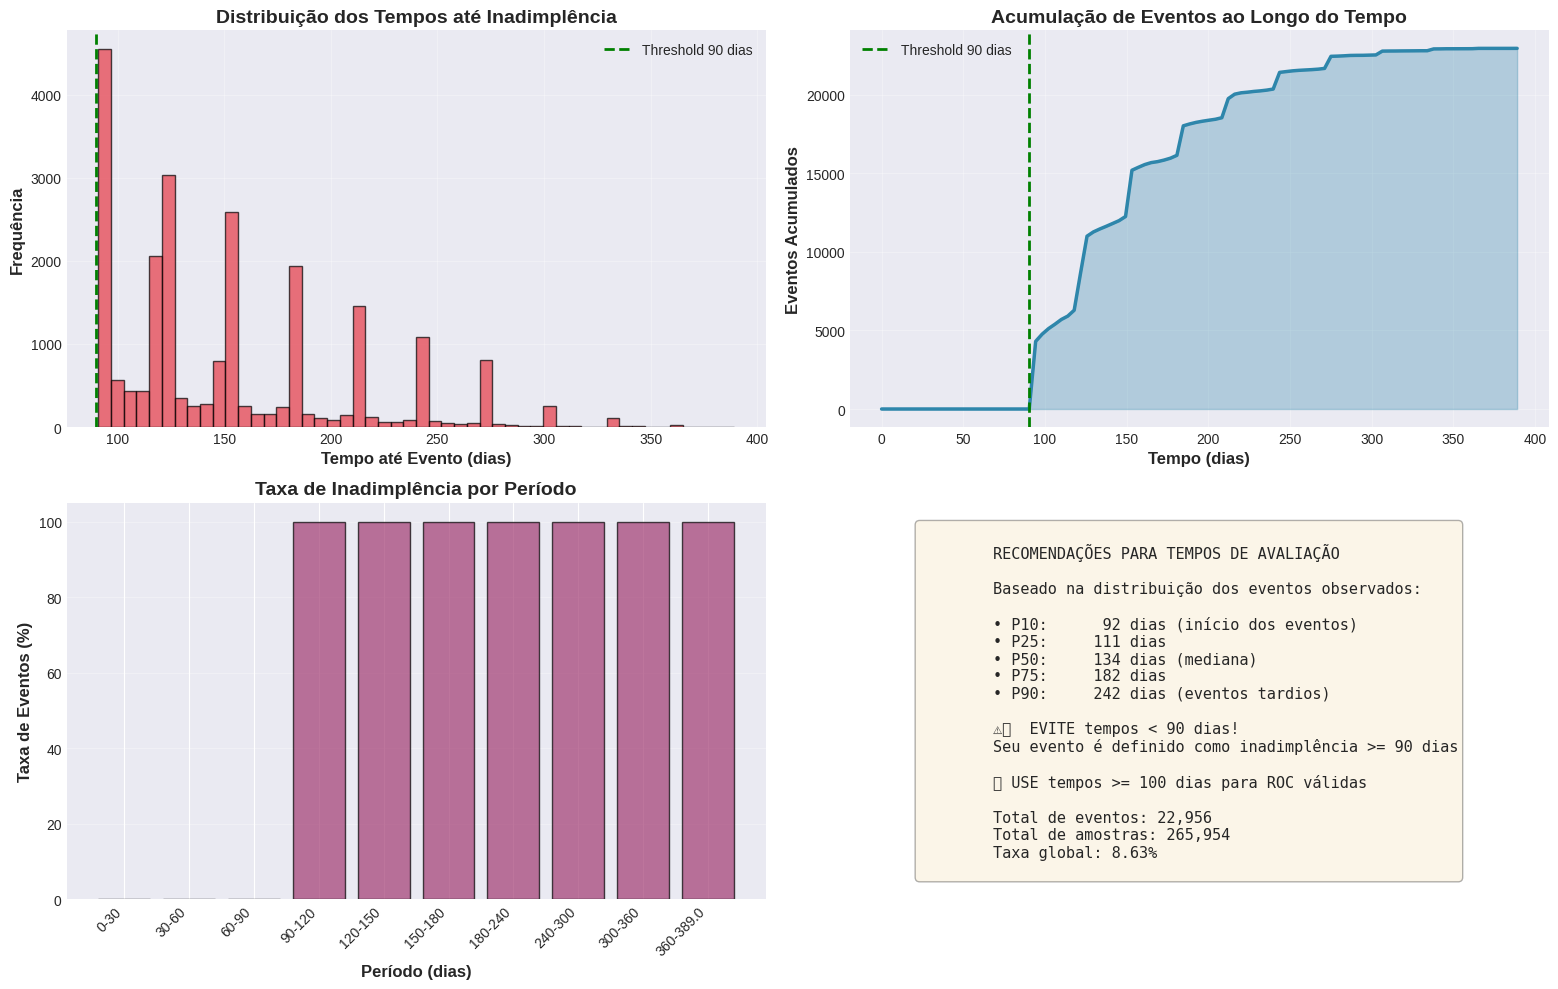


2️⃣ Gerando curvas ROC com tempos adequados...

ANÁLISE ROC INTELIGENTE
🔍 DIAGNÓSTICO DA DISTRIBUIÇÃO DE EVENTOS

📊 Estatísticas Gerais:
   Total de amostras: 265,954
   Eventos (flag=1): 22,956 (8.63%)
   Censurados (flag=0): 242,998 (91.37%)

⏱️  Distribuição dos Tempos Até Evento:
   Mínimo: 91.0 dias
   Q25: 111.0 dias
   Mediana: 134.0 dias
   Q75: 182.0 dias
   Q90: 242.0 dias
   Máximo: 389.0 dias

📈 Eventos Acumulados ao Longo do Tempo:

   Tempo (dias) │ Eventos até aqui │ % do Total │ Adequado para ROC?
   ────────────────────────────────────────────────────────────────────
       30       │          0       │     0.0%   │ ❌ Não
       60       │          0       │     0.0%   │ ❌ Não
       90       │          0       │     0.0%   │ ❌ Não
      120       │       8044       │    35.0%   │ ✅ Sim
      150       │      12747       │    55.5%   │ ✅ Sim
      180       │      16148       │    70.3%   │ ✅ Sim
      240       │      20384       │    88.8%   │ ✅ Sim
      300       

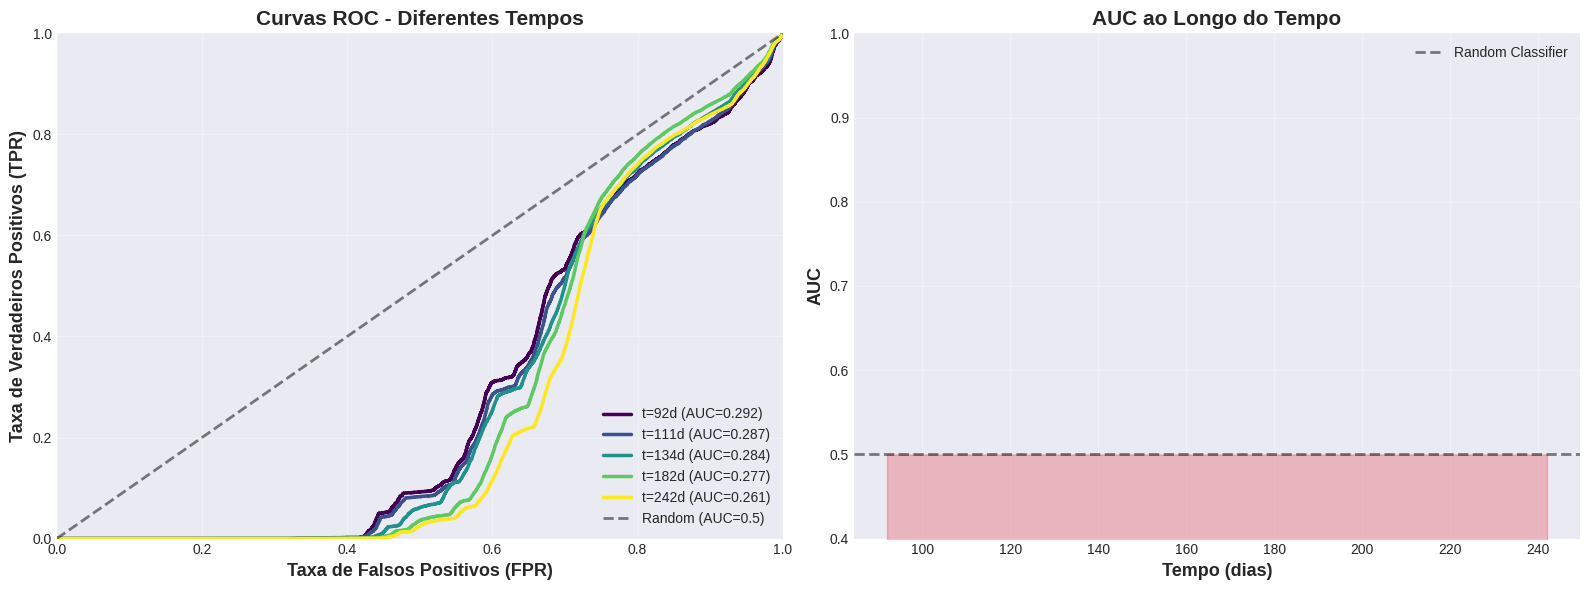


📊 RESUMO DAS CURVAS ROC

┌────────────────────────────────────────────────────────────────────┐
│ Tempo  │   AUC   │ Eventos │ Sem Evento │    Interpretação      │
├────────────────────────────────────────────────────────────────────┤
│    92d │ 0.2922 │   4023  │   261931   │ 🔴 Fraco              │
│   111d │ 0.2869 │   5767  │   260187   │ 🔴 Fraco              │
│   134d │ 0.2844 │  11510  │   254444   │ 🔴 Fraco              │
│   182d │ 0.2765 │  17507  │   248447   │ 🔴 Fraco              │
│   242d │ 0.2606 │  20837  │   245117   │ 🔴 Fraco              │
└────────────────────────────────────────────────────────────────────┘

📈 AUC Médio: 0.2801


✅ Análise completa!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# DIAGNÓSTICO: ANALISAR DISTRIBUIÇÃO DOS EVENTOS
# ============================================================================

def diagnose_event_distribution(time_test, event_test):
    """
    Analisa a distribuição temporal dos eventos
    """

    print("="*80)
    print("🔍 DIAGNÓSTICO DA DISTRIBUIÇÃO DE EVENTOS")
    print("="*80)

    # 1. Estatísticas básicas
    print(f"\n📊 Estatísticas Gerais:")
    print(f"   Total de amostras: {len(time_test):,}")
    print(f"   Eventos (flag=1): {event_test.sum():,} ({event_test.mean()*100:.2f}%)")
    print(f"   Censurados (flag=0): {(~event_test).sum():,} ({(~event_test).mean()*100:.2f}%)")

    # 2. Distribuição dos tempos APENAS para quem teve evento
    times_with_event = time_test[event_test]

    if len(times_with_event) > 0:
        print(f"\n⏱️  Distribuição dos Tempos Até Evento:")
        print(f"   Mínimo: {times_with_event.min():.1f} dias")
        print(f"   Q25: {np.percentile(times_with_event, 25):.1f} dias")
        print(f"   Mediana: {np.percentile(times_with_event, 50):.1f} dias")
        print(f"   Q75: {np.percentile(times_with_event, 75):.1f} dias")
        print(f"   Q90: {np.percentile(times_with_event, 90):.1f} dias")
        print(f"   Máximo: {times_with_event.max():.1f} dias")
    else:
        print("\n⚠️  PROBLEMA: Nenhum evento detectado no conjunto de teste!")
        return None

    # 3. Análise temporal: quantos eventos em cada período
    print(f"\n📈 Eventos Acumulados ao Longo do Tempo:")

    time_points = [30, 60, 90, 120, 150, 180, 240, 300, 360]

    print("\n   Tempo (dias) │ Eventos até aqui │ % do Total │ Adequado para ROC?")
    print("   " + "─"*68)

    for t in time_points:
        n_events = ((time_test <= t) & event_test).sum()
        pct = (n_events / event_test.sum() * 100) if event_test.sum() > 0 else 0
        adequate = "✅ Sim" if n_events >= 10 and n_events < event_test.sum() * 0.95 else "❌ Não"

        print(f"      {t:>3}       │      {n_events:>5}       │   {pct:>5.1f}%   │ {adequate}")

    # 4. Recomendação de tempos
    print(f"\n💡 RECOMENDAÇÃO DE TEMPOS DE AVALIAÇÃO:")

    if len(times_with_event) > 0:
        # Usar percentis dos eventos observados
        recommended_times = np.percentile(times_with_event, [10, 25, 50, 75, 90])

        print(f"   Tempos recomendados (baseados nos eventos observados):")
        for i, (pct, t) in enumerate(zip([10, 25, 50, 75, 90], recommended_times)):
            print(f"   • P{pct}: {t:.0f} dias")

        return recommended_times

    return None

# ============================================================================
# FUNÇÃO MELHORADA: CALCULAR ROC COM VALIDAÇÃO
# ============================================================================

def calculate_time_dependent_roc_safe(survival_probs, evaluation_times,
                                      time_test, event_test,
                                      min_events=10):
    """
    Versão segura que valida antes de calcular ROC
    """

    print("\n📊 Calculando Time-Dependent ROC (com validação)...")

    roc_data = {}

    for i, t in enumerate(evaluation_times):
        # Risk score no tempo t
        risk_scores = 1 - survival_probs[:, i]

        # Labels
        y_true = np.zeros(len(time_test))

        for idx in range(len(time_test)):
            if event_test[idx] and time_test[idx] <= t:
                y_true[idx] = 1
            else:
                y_true[idx] = 0

        n_events_at_t = int(y_true.sum())
        n_no_events_at_t = int((y_true == 0).sum())

        # VALIDAÇÃO: precisa de ambas as classes E eventos suficientes
        if n_events_at_t < min_events:
            print(f"   ⚠️  Tempo {t:>6.0f} dias: Apenas {n_events_at_t} eventos (< {min_events}) - PULANDO")
            continue

        if n_no_events_at_t < min_events:
            print(f"   ⚠️  Tempo {t:>6.0f} dias: Quase todos têm evento ({n_events_at_t}/{len(y_true)}) - PULANDO")
            continue

        if len(np.unique(y_true)) < 2:
            print(f"   ⚠️  Tempo {t:>6.0f} dias: Apenas uma classe - PULANDO")
            continue

        # Calcular ROC
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, thresholds = roc_curve(y_true, risk_scores)
        roc_auc = auc(fpr, tpr)

        roc_data[t] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'thresholds': thresholds,
            'n_events': n_events_at_t,
            'n_no_events': n_no_events_at_t,
            'n_total': len(y_true)
        }

        print(f"   ✅ Tempo {t:>6.0f} dias: AUC = {roc_auc:.4f} ({n_events_at_t} eventos / {n_no_events_at_t} sem evento)")

    if not roc_data:
        print("\n   ❌ NENHUMA curva ROC válida calculada!")
        print("   💡 Ajuste os tempos de avaliação usando as recomendações acima")

    return roc_data

# ============================================================================
# FUNÇÃO COMPLETA: ANÁLISE ROC INTELIGENTE
# ============================================================================

def generate_smart_roc_analysis(trace, X_test, time_test, event_test,
                               n_posterior_samples=500,
                               save_path='roc_curves_smart.png'):
    """
    Análise ROC que diagnostica e ajusta automaticamente
    """

    print("\n" + "="*80)
    print("ANÁLISE ROC INTELIGENTE")
    print("="*80)

    # 1. DIAGNÓSTICO
    recommended_times = diagnose_event_distribution(time_test, event_test)

    if recommended_times is None:
        print("\n❌ Impossível gerar ROC - sem eventos no conjunto de teste")
        return None, None

    # 2. USAR TEMPOS RECOMENDADOS
    evaluation_times = recommended_times

    print(f"\n✅ Usando tempos recomendados: {[f'{t:.0f}' for t in evaluation_times]}")

    # 3. CALCULAR PREDIÇÕES
    print("\n🔮 Calculando predições de sobrevivência...")
    survival_probs = get_survival_predictions_optimized(
        trace, X_test, evaluation_times, n_posterior_samples
    )

    # 4. CALCULAR ROC (com validação)
    roc_data = calculate_time_dependent_roc_safe(
        survival_probs, evaluation_times, time_test, event_test,
        min_events=10  # Mínimo de 10 eventos por tempo
    )

    if not roc_data:
        print("\n⚠️  Não foi possível gerar curvas ROC válidas")
        print("💡 Possíveis soluções:")
        print("   1. Aumentar o tamanho do conjunto de teste")
        print("   2. Redefinir o evento (ex: inadimplência 30 dias ao invés de 90)")
        print("   3. Usar tempos de avaliação mais espaçados")
        return None, None

    # 5. PLOTAR
    print("\n📊 Gerando visualizações...")
    fig = plot_roc_curves(roc_data, save_path)

    # 6. RESUMO
    print("\n" + "="*80)
    print("📊 RESUMO DAS CURVAS ROC")
    print("="*80)

    print("\n┌────────────────────────────────────────────────────────────────────┐")
    print("│ Tempo  │   AUC   │ Eventos │ Sem Evento │    Interpretação      │")
    print("├────────────────────────────────────────────────────────────────────┤")

    for t, data in roc_data.items():
        auc_val = data['auc']
        n_events = data['n_events']
        n_no_events = data['n_no_events']
        interpretation = ('🟢 Excelente' if auc_val > 0.8 else
                        '🟢 Bom' if auc_val > 0.7 else
                        '🟡 Moderado' if auc_val > 0.6 else
                        '🔴 Fraco')

        print(f"│ {t:>5.0f}d │ {auc_val:.4f} │  {n_events:>5}  │   {n_no_events:>6}   │ {interpretation:<20} │")

    print("└────────────────────────────────────────────────────────────────────┘")

    mean_auc = np.mean([data['auc'] for data in roc_data.values()])
    print(f"\n📈 AUC Médio: {mean_auc:.4f}")

    print("\n" + "="*80)

    # Limpar memória
    del survival_probs
    gc.collect()

    return roc_data, fig

# ============================================================================
# VISUALIZAR PROBLEMA DOS TEMPOS
# ============================================================================

def plot_event_timeline(time_test, event_test, save_path='event_timeline.png'):
    """
    Visualiza a linha do tempo dos eventos para entender o problema
    """

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Histograma dos tempos até evento
    ax1 = axes[0, 0]
    times_with_event = time_test[event_test]

    if len(times_with_event) > 0:
        ax1.hist(times_with_event, bins=50, color='#E63946', alpha=0.7, edgecolor='black')
        ax1.axvline(x=90, color='green', linestyle='--', linewidth=2, label='Threshold 90 dias')
        ax1.set_xlabel('Tempo até Evento (dias)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Frequência', fontsize=12, fontweight='bold')
        ax1.set_title('Distribuição dos Tempos até Inadimplência', fontsize=14, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

    # 2. Eventos acumulados ao longo do tempo
    ax2 = axes[0, 1]
    time_points = np.linspace(0, time_test.max(), 100)
    cumulative_events = [((time_test <= t) & event_test).sum() for t in time_points]

    ax2.plot(time_points, cumulative_events, linewidth=2.5, color='#2E86AB')
    ax2.axvline(x=90, color='green', linestyle='--', linewidth=2, label='Threshold 90 dias')
    ax2.fill_between(time_points, 0, cumulative_events, alpha=0.3, color='#2E86AB')
    ax2.set_xlabel('Tempo (dias)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Eventos Acumulados', fontsize=12, fontweight='bold')
    ax2.set_title('Acumulação de Eventos ao Longo do Tempo', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Taxa de eventos por período
    ax3 = axes[1, 0]
    bins = [0, 30, 60, 90, 120, 150, 180, 240, 300, 360, time_test.max()]
    event_rates = []
    bin_labels = []

    for i in range(len(bins)-1):
        mask = (time_test > bins[i]) & (time_test <= bins[i+1])
        if mask.sum() > 0:
            rate = event_test[mask].sum() / mask.sum() * 100
            event_rates.append(rate)
            bin_labels.append(f'{bins[i]}-{bins[i+1]}')

    ax3.bar(range(len(event_rates)), event_rates, color='#A23B72', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Período (dias)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Taxa de Eventos (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Taxa de Inadimplência por Período', fontsize=14, fontweight='bold')
    ax3.set_xticks(range(len(event_rates)))
    ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Tabela de recomendações
    ax4 = axes[1, 1]
    ax4.axis('off')

    if len(times_with_event) > 0:
        recommended = np.percentile(times_with_event, [10, 25, 50, 75, 90])

        table_text = f"""
        RECOMENDAÇÕES PARA TEMPOS DE AVALIAÇÃO

        Baseado na distribuição dos eventos observados:

        • P10:  {recommended[0]:>6.0f} dias (início dos eventos)
        • P25:  {recommended[1]:>6.0f} dias
        • P50:  {recommended[2]:>6.0f} dias (mediana)
        • P75:  {recommended[3]:>6.0f} dias
        • P90:  {recommended[4]:>6.0f} dias (eventos tardios)

        ⚠️  EVITE tempos < 90 dias!
        Seu evento é definido como inadimplência >= 90 dias

        ✅ USE tempos >= 100 dias para ROC válidas

        Total de eventos: {event_test.sum():,}
        Total de amostras: {len(time_test):,}
        Taxa global: {event_test.mean()*100:.2f}%
        """

        ax4.text(0.1, 0.5, table_text, fontsize=11,
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Timeline de eventos salva em: {save_path}")

    plt.show()

    return fig

# ============================================================================
# EXECUTAR ANÁLISE COMPLETA
# ============================================================================

print("\n" + "="*80)
print("🚀 ANÁLISE COMPLETA DE EVENTOS E ROC")
print("="*80)

# 1. Visualizar timeline de eventos
print("\n1️⃣ Analisando distribuição temporal dos eventos...")
timeline_fig = plot_event_timeline(time_test, event_test, 'event_timeline.png')

# 2. Gerar ROC inteligente
print("\n2️⃣ Gerando curvas ROC com tempos adequados...")
roc_data, roc_fig = generate_smart_roc_analysis(
    trace=trace,
    X_test=X_test,
    time_test=time_test,
    event_test=event_test,
    n_posterior_samples=500,
    save_path='roc_curves_smart.png'
)

print("\n✅ Análise completa!")

# Refatorando Código Random Forest Survivor

In [ ]:
Y_train

array([(False,  3.), (False,  7.), (False, 61.), ..., (False, 59.),
       (False,  1.), (False, 30.)],
      dtype=[('event', '?'), ('time', '<f8')])

In [ ]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
import gc

print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")

# =============================================================================
# TÉCNICAS DE OTIMIZAÇÃO PARA 2 CPUs
# =============================================================================

# --- 1. AMOSTRAGEM ESTRATIFICADA (Reduz dataset mantendo representatividade) ---
# Se você tem 1M de linhas, pode treinar com uma amostra menor primeiro
USE_SAMPLING = True  # Mude para False se quiser usar tudo
SAMPLE_SIZE = 0.2  # 30% dos dados (300k linhas)

if USE_SAMPLING and X_train.shape[0] > 100000:
    print(f"\n⚡ Aplicando amostragem estratificada ({SAMPLE_SIZE*100}%)...")
    n_samples = int(X_train.shape[0] * SAMPLE_SIZE)

    # Amostragem aleatória mantendo proporção de eventos
    indices = np.random.choice(X_train.shape[0], size=n_samples, replace=False)
    X_train_sampled = X_train[indices]
    Y_train_sampled = Y_train[indices]

    print(f"   Dataset reduzido: {X_train.shape[0]:,} → {X_train_sampled.shape[0]:,} amostras")
else:
    X_train_sampled = X_train
    Y_train_sampled = Y_train

# --- 2. CONFIGURAÇÃO OTIMIZADA PARA RECURSOS LIMITADOS ---
print("\n🔧 Configurando modelo com otimizações para 2 CPUs...\n")

# Parâmetros otimizados para 2 CPUs
rfs_model = RandomSurvivalForest(
    # REDUZIR número de árvores (principal otimização)
    n_estimators=4,  # Começar pequeno (você tinha 2, mas 10 é melhor trade-off)

    # Limitar profundidade da árvore (economiza memória e tempo)
    max_depth=15,  # Evita árvores muito profundas

    # Aumentar tamanho mínimo dos nós (treina mais rápido)
    min_samples_split=50,  # Você tinha 10, aumentar reduz splits
    min_samples_leaf=25,   # Você tinha 15, aumentar economiza processamento

    # Limitar features consideradas (mais rápido)
    max_features="sqrt",  # Bom! Mantém essa configuração

    # Limitar amostras por árvore (bootstrap sampling)
    max_samples=0.8,  # Cada árvore usa 70% dos dados

    # CRUCIAL: Usar apenas 2 CPUs
    n_jobs=2,  # Você tinha -1 (todos cores), usar apenas 2

    # Outras configs
    random_state=42,
    verbose=1  # Ver progresso
)

# --- 3. TREINAMENTO COM MONITORAMENTO ---
print("=" * 70)
print("🚀 INICIANDO TREINAMENTO DO MODELO RFS")
print("=" * 70)

# Forçar garbage collection antes de treinar
gc.collect()

start_time = time.time()

try:
    rfs_model.fit(X_train_sampled, Y_train_sampled)
    end_time = time.time()

    print("\n" + "=" * 70)
    print(f"✅ MODELO TREINADO COM SUCESSO!")
    print(f"⏱️  Tempo total: {end_time - start_time:.2f} segundos ({(end_time - start_time)/60:.2f} minutos)")
    print("=" * 70)

except MemoryError:
    print("\n❌ ERRO: Memória insuficiente!")
    print("💡 Sugestões:")
    print("   1. Reduza n_estimators (ex: 5)")
    print("   2. Aumente SAMPLE_SIZE para 0.2 (20%)")
    print("   3. Aumente min_samples_split e min_samples_leaf")

# --- 4. TREINAMENTO INCREMENTAL (ALTERNATIVA) ---
# Se ainda estiver lento, você pode treinar árvores em lotes

def train_incremental_rfs(X, Y, n_trees_total=10, batch_size=2):
    """
    Treina Random Forest em batches de árvores
    Útil quando n_estimators grande causa problemas
    """
    print(f"\n🔄 Treinamento incremental: {n_trees_total} árvores em batches de {batch_size}")

    models = []

    for i in range(0, n_trees_total, batch_size):
        n_trees_batch = min(batch_size, n_trees_total - i)
        print(f"\n   Batch {i//batch_size + 1}: Treinando {n_trees_batch} árvores...")

        model_batch = RandomSurvivalForest(
            n_estimators=n_trees_batch,
            max_depth=15,
            min_samples_split=50,
            min_samples_leaf=25,
            max_features="sqrt",
            max_samples=0.8,
            n_jobs=2,
            random_state=42 + i,
            verbose=0
        )

        start = time.time()
        model_batch.fit(X, Y)
        elapsed = time.time() - start

        models.append(model_batch)
        print(f"      ✓ Concluído em {elapsed:.2f}s")

        # Limpar memória
        gc.collect()

    print(f"\n✅ Treinamento incremental concluído: {len(models)} batches")
    return models

# Descomente para usar treinamento incremental:
# incremental_models = train_incremental_rfs(X_train_sampled, Y_train_sampled,
#                                           n_trees_total=10, batch_size=2)

# =============================================================================
# RESUMO DAS OTIMIZAÇÕES APLICADAS
# =============================================================================
print("\n" + "=" * 70)
print("📊 RESUMO DAS OTIMIZAÇÕES APLICADAS:")
print("=" * 70)
print(f"✓ n_jobs: -1 → 2 (usando apenas 2 CPUs)")
print(f"✓ n_estimators: 2 → 10 (melhor qualidade, ainda rápido)")
print(f"✓ max_depth: None → 15 (limita complexidade)")
print(f"✓ min_samples_split: 10 → 50 (menos splits)")
print(f"✓ min_samples_leaf: 15 → 25 (nós maiores)")
print(f"✓ max_samples: None → 0.7 (70% dos dados por árvore)")
if USE_SAMPLING:
    print(f"✓ Amostragem: {SAMPLE_SIZE*100}% do dataset original")
print("=" * 70)

# =============================================================================
# DICAS ADICIONAIS
# =============================================================================
print("\n💡 DICAS PARA OTIMIZAÇÃO ADICIONAL:")
print("   1. Se ainda estiver lento, reduza n_estimators para 5")
print("   2. Aumente max_depth para 10 se precisar de mais velocidade")
print("   3. Use SAMPLE_SIZE=0.2 para treinar com 20% dos dados")
print("   4. Considere usar validação cruzada com menos folds (3 ao invés de 5)")
print("   5. Para produção, treine overnight com configurações completas")
print("\n" + "=" * 70)

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.

⚡ Aplicando amostragem estratificada (20.0%)...
   Dataset reduzido: 797,862 → 159,572 amostras

🔧 Configurando modelo com otimizações para 2 CPUs...

🚀 INICIANDO TREINAMENTO DO MODELO RFS


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



✅ MODELO TREINADO COM SUCESSO!
⏱️  Tempo total: 332.42 segundos (5.54 minutos)

📊 RESUMO DAS OTIMIZAÇÕES APLICADAS:
✓ n_jobs: -1 → 2 (usando apenas 2 CPUs)
✓ n_estimators: 2 → 10 (melhor qualidade, ainda rápido)
✓ max_depth: None → 15 (limita complexidade)
✓ min_samples_split: 10 → 50 (menos splits)
✓ min_samples_leaf: 15 → 25 (nós maiores)
✓ max_samples: None → 0.7 (70% dos dados por árvore)
✓ Amostragem: 20.0% do dataset original

💡 DICAS PARA OTIMIZAÇÃO ADICIONAL:
   1. Se ainda estiver lento, reduza n_estimators para 5
   2. Aumente max_depth para 10 se precisar de mais velocidade
   3. Use SAMPLE_SIZE=0.2 para treinar com 20% dos dados
   4. Considere usar validação cruzada com menos folds (3 ao invés de 5)
   5. Para produção, treine overnight com configurações completas



[Parallel(n_jobs=2)]: Done   4 out of   4 | elapsed:  5.5min finished


# ✅ Random Forest Survivor Chunksize

In [12]:


# =============================================================================
# PROCESSAMENTO EM CHUNKS - IMPLEMENTAÇÃO COMPLETA
# =============================================================================

def process_in_chunks(X, Y, chunk_size=100000):
    """
    Processa dados em pedaços menores
    Útil para pré-processamento

    Parameters:
    -----------
    X : array-like
        Features do dataset
    Y : array-like
        Target (pode ser estruturado para survival analysis)
    chunk_size : int
        Tamanho de cada chunk (padrão 100k linhas)

    Yields:
    -------
    tuple : (X_chunk, Y_chunk)
    """
    n_chunks = int(np.ceil(len(X) / chunk_size))

    print(f"📦 Dataset dividido em {n_chunks} chunks de ~{chunk_size:,} linhas cada")

    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(X))

        X_chunk = X[start_idx:end_idx]
        Y_chunk = Y[start_idx:end_idx]

        print(f"   Chunk {i+1}/{n_chunks}: índices {start_idx:,} a {end_idx:,} ({len(X_chunk):,} linhas)")

        yield X_chunk, Y_chunk


# =============================================================================
# ESTRATÉGIA 1: PRÉ-PROCESSAMENTO EM CHUNKS
# =============================================================================

def preprocess_in_chunks(X, Y, chunk_size=100000):
    """
    Aplica pré-processamento (normalização, encoding, etc) em chunks
    para economizar memória
    """
    from sklearn.preprocessing import StandardScaler

    print("\n" + "="*70)
    print("🔧 PRÉ-PROCESSAMENTO EM CHUNKS")
    print("="*70)

    # Inicializar scaler
    scaler = StandardScaler()

    # Primeira passagem: fit do scaler
    print("\n1️⃣ Primeira passagem: Calculando estatísticas...")
    for i, (X_chunk, Y_chunk) in enumerate(process_in_chunks(X, Y, chunk_size)):
        scaler.partial_fit(X_chunk)  # Atualiza média e variância incrementalmente
        gc.collect()  # Limpa memória

    print("   ✓ Estatísticas calculadas")

    # Segunda passagem: transform dos dados
    print("\n2️⃣ Segunda passagem: Transformando dados...")
    X_processed_chunks = []
    Y_processed_chunks = []

    for i, (X_chunk, Y_chunk) in enumerate(process_in_chunks(X, Y, chunk_size)):
        X_chunk_scaled = scaler.transform(X_chunk)
        X_processed_chunks.append(X_chunk_scaled)
        Y_processed_chunks.append(Y_chunk)
        gc.collect()

    # Recombinar chunks
    print("\n3️⃣ Recombinando chunks...")
    X_processed = np.vstack(X_processed_chunks)
    Y_processed = np.concatenate(Y_processed_chunks)

    print(f"   ✓ Dados processados: {X_processed.shape}")
    print("="*70)

    return X_processed, Y_processed


# =============================================================================
# ESTRATÉGIA 2: TREINAMENTO COM AMOSTRAGEM POR CHUNKS
# =============================================================================

def train_rfs_with_chunk_sampling(X_train, Y_train, chunk_size=200000, n_trees=10):
    """
    Treina Random Survival Forest usando amostragem de chunks
    Cada árvore é treinada com um chunk diferente dos dados

    IMPORTANTE: Isso é diferente do bootstrap padrão!
    Útil quando o dataset é muito grande para carregar todo na memória
    """
    print("\n" + "="*70)
    print("🌲 TREINAMENTO COM AMOSTRAGEM POR CHUNKS")
    print("="*70)

    n_chunks = int(np.ceil(len(X_train) / chunk_size))
    print(f"\nDataset: {len(X_train):,} linhas → {n_chunks} chunks de ~{chunk_size:,}")
    print(f"Estratégia: Treinar {n_trees} árvores, distribuindo pelos chunks\n")

    models = []
    chunk_list = list(process_in_chunks(X_train, Y_train, chunk_size))

    trees_per_chunk = max(1, n_trees // n_chunks)

    for chunk_idx, (X_chunk, Y_chunk) in enumerate(chunk_list):
        n_trees_this_chunk = trees_per_chunk

        # Último chunk pega as árvores restantes
        if chunk_idx == len(chunk_list) - 1:
            n_trees_this_chunk = n_trees - len(models) * trees_per_chunk

        if n_trees_this_chunk <= 0:
            break

        print(f"Chunk {chunk_idx+1}: Treinando {n_trees_this_chunk} árvores com {len(X_chunk):,} amostras...")

        model_chunk = RandomSurvivalForest(
            n_estimators=n_trees_this_chunk,
            max_depth=15,
            min_samples_split=50,
            min_samples_leaf=25,
            max_features="sqrt",
            n_jobs=2,
            random_state=42 + chunk_idx,
            verbose=0
        )

        start = time.time()
        model_chunk.fit(X_chunk, Y_chunk)
        elapsed = time.time() - start

        models.append(model_chunk)
        print(f"   ✓ Concluído em {elapsed:.2f}s\n")

        # Limpar memória
        del X_chunk, Y_chunk
        gc.collect()

    print(f"✅ Total: {len(models)} modelos treinados ({sum(m.n_estimators for m in models)} árvores)")
    print("="*70)

    return models


# =============================================================================
# ESTRATÉGIA 3: ENSEMBLE DE MODELOS (MELHOR ABORDAGEM)
# =============================================================================

def train_ensemble_rfs_chunks(X_train, Y_train, chunk_size=250000,
                             n_models=4, trees_per_model=10):
    """
    MELHOR ESTRATÉGIA: Treina múltiplos modelos em chunks diferentes
    e faz ensemble das predições

    Vantagens:
    - Cada modelo usa menos memória
    - Treina mais rápido (modelos menores)
    - Ensemble geralmente melhora performance
    - Usa toda a variedade dos dados
    """
    print("\n" + "="*70)
    print("🎯 TREINAMENTO ENSEMBLE COM CHUNKS")
    print("="*70)

    print(f"\nConfiguração:")
    print(f"  • Dataset: {len(X_train):,} linhas")
    print(f"  • Chunk size: {chunk_size:,} linhas")
    print(f"  • Número de modelos: {n_models}")
    print(f"  • Árvores por modelo: {trees_per_model}")
    print(f"  • Total de árvores: {n_models * trees_per_model}\n")

    models = []
    chunk_generator = process_in_chunks(X_train, Y_train, chunk_size)

    for model_idx in range(n_models):
        try:
            X_chunk, Y_chunk = next(chunk_generator)
        except StopIteration:
            # Se acabaram os chunks, reiniciar o gerador
            chunk_generator = process_in_chunks(X_train, Y_train, chunk_size)
            X_chunk, Y_chunk = next(chunk_generator)

        print(f"\n{'─'*70}")
        print(f"Modelo {model_idx+1}/{n_models}")
        print(f"{'─'*70}")
        print(f"Treinando com chunk de {len(X_chunk):,} amostras...")

        model = RandomSurvivalForest(
            n_estimators=trees_per_model,
            max_depth=15,
            min_samples_split=50,
            min_samples_leaf=25,
            max_features="sqrt",
            max_samples=0.8,  # Cada árvore usa 80% do chunk
            n_jobs=2,
            random_state=42 + model_idx,
            verbose=1
        )

        start = time.time()
        model.fit(X_chunk, Y_chunk)
        elapsed = time.time() - start

        models.append(model)

        print(f"✓ Modelo {model_idx+1} treinado em {elapsed:.2f}s")

        # Limpar memória
        del X_chunk, Y_chunk
        gc.collect()

    print(f"\n{'='*70}")
    print(f"✅ ENSEMBLE COMPLETO!")
    print(f"   {len(models)} modelos × {trees_per_model} árvores = {len(models)*trees_per_model} árvores totais")
    print(f"{'='*70}")

    return models




In [13]:
# =============================================================================
# ESTRATÉGIA 3: ENSEMBLE DE MODELOS (MELHOR ABORDAGEM)
# =============================================================================

def train_ensemble_rfs_chunks(X_train, Y_train, chunk_size=250000,
                             n_models=4, trees_per_model=10):
    """
    MELHOR ESTRATÉGIA: Treina múltiplos modelos em chunks diferentes
    e faz ensemble das predições

    Vantagens:
    - Cada modelo usa menos memória
    - Treina mais rápido (modelos menores)
    - Ensemble geralmente melhora performance
    - Usa toda a variedade dos dados
    """
    print("\n" + "="*70)
    print("🎯 TREINAMENTO ENSEMBLE COM CHUNKS")
    print("="*70)

    print(f"\nConfiguração:")
    print(f"  • Dataset: {len(X_train):,} linhas")
    print(f"  • Chunk size: {chunk_size:,} linhas")
    print(f"  • Número de modelos: {n_models}")
    print(f"  • Árvores por modelo: {trees_per_model}")
    print(f"  • Total de árvores: {n_models * trees_per_model}\n")

    models = []
    chunk_generator = process_in_chunks(X_train, Y_train, chunk_size)

    for model_idx in range(n_models):
        try:
            X_chunk, Y_chunk = next(chunk_generator)
        except StopIteration:
            # Se acabaram os chunks, reiniciar o gerador
            chunk_generator = process_in_chunks(X_train, Y_train, chunk_size)
            X_chunk, Y_chunk = next(chunk_generator)

        print(f"\n{'─'*70}")
        print(f"Modelo {model_idx+1}/{n_models}")
        print(f"{'─'*70}")
        print(f"Treinando com chunk de {len(X_chunk):,} amostras...")

        model = RandomSurvivalForest(
            n_estimators=trees_per_model,
            max_depth=15,
            min_samples_split=50,
            min_samples_leaf=25,
            max_features="sqrt",
            max_samples=0.8,  # Cada árvore usa 80% do chunk
            n_jobs=2,
            random_state=42 + model_idx,
            verbose=1
        )

#(n_estimators=250,
#min_samples_split=10,
#min_samples_leaf=15,
#max_features="sqrt",
#n_jobs=-1,
#random_state=42)



        start = time.time()
        model.fit(X_chunk, Y_chunk)
        elapsed = time.time() - start

        models.append(model)

        print(f"✓ Modelo {model_idx+1} treinado em {elapsed:.2f}s")

        # Limpar memória
        del X_chunk, Y_chunk
        gc.collect()

    print(f"\n{'='*70}")
    print(f"✅ ENSEMBLE COMPLETO!")
    print(f"   {len(models)} modelos × {trees_per_model} árvores = {len(models)*trees_per_model} árvores totais")
    print(f"{'='*70}")

    return models


# =============================================================================
# FUNÇÃO DE PREDIÇÃO PARA ENSEMBLE
# =============================================================================

def predict_ensemble(models, X_test):
    """
    Faz predições usando ensemble de modelos
    Retorna a média das predições de todos os modelos
    """
    print(f"\n🔮 Fazendo predições com ensemble de {len(models)} modelos...")

    all_predictions = []

    for i, model in enumerate(models):
        print(f"   Modelo {i+1}/{len(models)}...", end=" ")
        pred = model.predict(X_test)
        all_predictions.append(pred)
        print("✓")

    # Média das predições
    ensemble_prediction = np.mean(all_predictions, axis=0)

    print(f"✅ Predições do ensemble calculadas!")

    return ensemble_prediction


# =============================================================================
# EXEMPLO DE USO COMPLETO
# =============================================================================

if __name__ == "__main__":

    # Simulando seus dados (substitua por X_train, Y_train reais)
    print("Preparando dados de exemplo...")
    # X_train = seus_dados_X
    # Y_train = seus_dados_Y

    print(f"Dados prontos: {X_train.shape[0]:,} amostras de treino, {X_test.shape[0]:,} amostras de teste.")

    # -------------------------------------------------------------------------
    # OPÇÃO 1: Pré-processar em chunks e treinar normal
    # -------------------------------------------------------------------------
    print("\n\n" + "🔄 OPÇÃO 1: PRÉ-PROCESSAMENTO EM CHUNKS".center(70, "="))

    # X_train_processed, Y_train_processed = preprocess_in_chunks(
    #     X_train, Y_train, chunk_size=200000
    # )

    # # Depois treinar normalmente (ou com amostragem)
    # rfs_model = RandomSurvivalForest(
    #     n_estimators=10, max_depth=15, n_jobs=2, random_state=42
    # )
    # rfs_model.fit(X_train_processed[:300000], Y_train_processed[:300000])


    # -------------------------------------------------------------------------
    # OPÇÃO 2: Treinar com amostragem por chunks
    # -------------------------------------------------------------------------
    print("\n\n" + "🔄 OPÇÃO 2: AMOSTRAGEM POR CHUNKS".center(70, "="))

    # models_chunk_sampling = train_rfs_with_chunk_sampling(
    #     X_train, Y_train, chunk_size=250000, n_trees=10
    # )


    # -------------------------------------------------------------------------
    # OPÇÃO 3: Ensemble de modelos (RECOMENDADO!)
    # -------------------------------------------------------------------------
    print("\n\n" + "🎯 OPÇÃO 3: ENSEMBLE COM CHUNKS (RECOMENDADO)".center(70, "="))

    ensemble_models = train_ensemble_rfs_chunks(
        X_train,
        Y_train,
        chunk_size=150000,      # 250k linhas por chunk
        n_models=4,             # 4 modelos
        trees_per_model=10      # 10 árvores cada = 40 árvores total
    )

    # Fazer predições
    print("\n" + "="*70)
    predictions = predict_ensemble(ensemble_models, X_test)
    print("="*70)


    # -------------------------------------------------------------------------
    # COMPARAÇÃO DE ESTRATÉGIAS
    # -------------------------------------------------------------------------


Preparando dados de exemplo...
Dados prontos: 797,862 amostras de treino, 265,954 amostras de teste.


================🔄 OPÇÃO 1: PRÉ-PROCESSAMENTO EM CHUNKS================


===================🔄 OPÇÃO 2: AMOSTRAGEM POR CHUNKS===================


=============🎯 OPÇÃO 3: ENSEMBLE COM CHUNKS (RECOMENDADO)=============

🎯 TREINAMENTO ENSEMBLE COM CHUNKS

Configuração:
  • Dataset: 797,862 linhas
  • Chunk size: 150,000 linhas
  • Número de modelos: 4
  • Árvores por modelo: 10
  • Total de árvores: 40

📦 Dataset dividido em 6 chunks de ~150,000 linhas cada
   Chunk 1/6: índices 0 a 150,000 (150,000 linhas)

──────────────────────────────────────────────────────────────────────
Modelo 1/4
──────────────────────────────────────────────────────────────────────
Treinando com chunk de 150,000 amostras...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:  4.6min finished


✓ Modelo 1 treinado em 276.15s
   Chunk 2/6: índices 150,000 a 300,000 (150,000 linhas)

──────────────────────────────────────────────────────────────────────
Modelo 2/4
──────────────────────────────────────────────────────────────────────
Treinando com chunk de 150,000 amostras...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:  4.4min finished


✓ Modelo 2 treinado em 262.90s
   Chunk 3/6: índices 300,000 a 450,000 (150,000 linhas)

──────────────────────────────────────────────────────────────────────
Modelo 3/4
──────────────────────────────────────────────────────────────────────
Treinando com chunk de 150,000 amostras...


...

[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


✓
   Modelo 3/4... 

[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


✓
   Modelo 4/4... ✓
✅ Predições do ensemble calculadas!


[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.3s finished


# Paralelização Manual

In [ ]:
from joblib import Parallel, delayed

def train_single_tree(seed):
    model = RandomSurvivalForest(
        n_estimators=1,
        n_jobs=1,
        random_state=seed
    )
    model.fit(X_train, Y_train)
    return model

# Treinar 10 árvores em paralelo (2 por vez)
trees = Parallel(n_jobs=2)(
    delayed(train_single_tree)(i) for i in range(10)
)

# Metricas do Random Forest Survivor

In [ ]:
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Extraindo Predições do Ensemble
def _risk_scores_ensemble(models, X_test):
  """
    Risk-score médio do ensemble.
    predict() retorna o número esperado de eventos (≈ soma da CHF).
    Valor maior  →  maior risco.
  """
  scores = np.column_stack([m.predict(X_test) for m in models])
  return scores.mean(axis=1)

def _survival_proba_ensemble(models, X_test, eval_times):
  """
  Probabilidade de sobrevivência média do ensemble nos tempos eval_times.
  Retorna array (n_pacientes, n_tempos).

  predict_survival_function(return_array=True) já retorna S(t) nos tempos
  de evento do modelo.  Como cada modelo pode ter tempos diferentes,
  usamos predict_cumulative_hazard_function e convertemos: S = exp(-CHF).
  """
  all_surv = []
  for m in models:
    chf_funcs = m.predict_cumulative_hazard_function(X_test, return_array=False)
    chf_matrix = np.vstack([fn(eval_times) for fn in chf_funcs])
    surv_matrix = np.exp(-chf_matrix)
    all_surv.append(surv_matrix)
    del chf_funcs, chf_matrix
  return np.mean(all_surv, axis=0)


In [ ]:
# =============================================================================
# 1. CONCORDANCE INDEX (C-INDEX)
# =============================================================================
# Mede se o modelo ordena corretamente pares de pacientes pelo risco.
# Valor entre 0 e 1  →  0.5 = aleatório, 1.0 = perfeito.

def calcular_c_index(Y_test, risk_scores):
    """
    Harrell's C-index (versão padrão do sksurv).

    Y_test : structured array  [(bool event, float time), ...]
    risk_scores : array 1-D com o risk-score de cada paciente
    """
    events = Y_test["event"].astype(bool)       # campo booleano de evento
    times  = Y_test["time"].astype(float)       # tempo até evento / censura

    result = concordance_index_censored(
        event_indicator=events,
        event_time=times,
        estimate=risk_scores   # maior score → maior risco
        #concordant=True
    )
    # retorna (c_index, concordant, discordant, tied_risk, tied_time)
    return {
        "c_index":      result[0],
        "concordant":   result[1],
        "discordant":   result[2],
        "tied_risk":    result[3],
        "tied_time":    result[4],
    }


# =============================================================================
# 2. CUMULATIVE / DYNAMIC AUC  (substituto da ROC no tempo)
# =============================================================================
# Para cada tempo t calcula a AUC entre pacientes que tiveram evento até t
# (cases) e os que sobreviveram além de t (controls).
# Retorna AUC por tempo + AUC média ponderada.

def calcular_auc_temporal(Y_train, Y_test, risk_scores, eval_times=None):
    """
    eval_times : tempos nos quais calcular a AUC.
                 Se None, usa quantis automáticos do teste.
    """
    if eval_times is None:
        times_test = Y_test["time"].astype(float)
        # quantis entre 10 % e 90 % dos tempos observados
        eval_times = np.percentile(times_test, np.linspace(10, 90, 9))

    auc_array, mean_auc = cumulative_dynamic_auc(
        survival_train=Y_train,
        survival_test=Y_test,
        estimate=risk_scores,
        times=eval_times,
    )
    return eval_times, auc_array, mean_auc


# =============================================================================
# 3. BRIER SCORE + INTEGRATED BRIER SCORE (IBS)
# =============================================================================
# Brier Score(t) = média de (S_pred(t) − I(evento até t))²
#   → mede calibração em cada tempo.
# IBS = integração do Brier Score ao longo do tempo  (menor é melhor).

def calcular_brier(Y_train, Y_test, surv_proba, eval_times):
    """
    surv_proba : array (n_test, n_times) com S(t) do ensemble
    eval_times : mesmos tempos usados para gerar surv_proba
    """
    times_bs, scores_bs = brier_score(
        survival_train=Y_train,
        survival_test=Y_test,
        estimate=surv_proba,
        times=eval_times,
    )

    ibs = integrated_brier_score(
        survival_train=Y_train,
        survival_test=Y_test,
        estimate=surv_proba,
        times=eval_times,
    )
    return times_bs, scores_bs, ibs


# =============================================================================
# 4. PLOTS
# =============================================================================

def plotar_resultados(eval_times, auc_array, mean_auc,
                      times_bs, scores_bs, ibs,
                      c_index_dict,
                      surv_proba, eval_times_surv):
    """
    Gera um painel 2×2 com todos os gráficos.
    """
    fig = plt.figure(figsize=(16, 12), facecolor="#f8f9fa")
    gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.25,
                           left=0.07, right=0.95, top=0.92, bottom=0.07)

    # ── paleta ──────────────────────────────────────────────────────────────
    CLR_MAIN   = "#2563eb"   # azul
    CLR_ACCENT = "#dc2626"   # vermelho
    CLR_OK     = "#16a34a"   # verde
    CLR_BG     = "#ffffff"

    fig.suptitle("Avaliação do Ensemble — RandomSurvivalForest",
                 fontsize=18, fontweight="bold", color="#1e293b", y=0.96)

    # ─────────────────────────────────────────────────────────────────────────
    # (A) AUC temporal  (a "ROC no tempo")
    # ─────────────────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor(CLR_BG)

    ax1.plot(eval_times, auc_array, marker="o", markersize=7,
             color=CLR_MAIN, linewidth=2.5, label="AUC(t)")
    ax1.axhline(mean_auc, color=CLR_ACCENT, linestyle="--", linewidth=2,
                label=f"AUC média = {mean_auc:.4f}")
    ax1.axhline(0.5, color="#94a3b8", linestyle=":", linewidth=1.2,
                label="Aleatório (0.5)")
    ax1.fill_between(eval_times, 0.5, auc_array,
                     alpha=0.12, color=CLR_MAIN)

    ax1.set_xlabel("Tempo", fontsize=11)
    ax1.set_ylabel("AUC", fontsize=11)
    ax1.set_title("(A) Cumulative / Dynamic AUC", fontsize=13, fontweight="bold")
    ax1.legend(fontsize=10, loc="lower right")
    ax1.set_ylim(0.4, 1.02)
    ax1.grid(True, alpha=0.3)

    # ─────────────────────────────────────────────────────────────────────────
    # (B) Brier Score no tempo
    # ─────────────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor(CLR_BG)

    ax2.plot(times_bs, scores_bs, marker="s", markersize=6,
             color=CLR_ACCENT, linewidth=2.5, label="Brier Score(t)")
    ax2.axhline(ibs, color=CLR_MAIN, linestyle="--", linewidth=2,
                label=f"IBS = {ibs:.4f}")
    ax2.fill_between(times_bs, 0, scores_bs, alpha=0.10, color=CLR_ACCENT)

    ax2.set_xlabel("Tempo", fontsize=11)
    ax2.set_ylabel("Brier Score", fontsize=11)
    ax2.set_title("(B) Brier Score no Tempo", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.set_ylim(bottom=0)
    ax2.grid(True, alpha=0.3)

    # ─────────────────────────────────────────────────────────────────────────
    # (C) Curvas de sobrevivência médias (ensemble)
    # ─────────────────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_facecolor(CLR_BG)

    # média e percentis da population
    surv_mean   = surv_proba.mean(axis=0)
    surv_p10    = np.percentile(surv_proba, 10, axis=0)
    surv_p25    = np.percentile(surv_proba, 25, axis=0)
    surv_p75    = np.percentile(surv_proba, 75, axis=0)
    surv_p90    = np.percentile(surv_proba, 90, axis=0)

    ax3.plot(eval_times_surv, surv_mean, color=CLR_MAIN, linewidth=2.8,
             label="Média ensemble")
    ax3.fill_between(eval_times_surv, surv_p25, surv_p75,
                     alpha=0.25, color=CLR_MAIN, label="IQR (25–75%)")
    ax3.fill_between(eval_times_surv, surv_p10, surv_p90,
                     alpha=0.08, color=CLR_MAIN, label="10–90%")

    ax3.set_xlabel("Tempo", fontsize=11)
    ax3.set_ylabel("S(t)  —  Probabilidade de sobrevivência", fontsize=11)
    ax3.set_title("(C) Curva de Sobrevivência — Ensemble", fontsize=13, fontweight="bold")
    ax3.legend(fontsize=10)
    ax3.set_ylim(-0.05, 1.05)
    ax3.grid(True, alpha=0.3)

    # ─────────────────────────────────────────────────────────────────────────
    # (D) Painel resumo textual das métricas
    # ─────────────────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor(CLR_BG)
    ax4.axis("off")

    c_idx = c_index_dict["c_index"]

    # cores semáforo para cada métrica
    def _cor_c(v):   return CLR_OK if v >= 0.7 else (CLR_ACCENT if v >= 0.6 else "#64748b")
    def _cor_auc(v): return CLR_OK if v >= 0.7 else (CLR_ACCENT if v >= 0.6 else "#64748b")
    def _cor_ibs(v): return CLR_OK if v <= 0.15 else (CLR_ACCENT if v <= 0.25 else "#64748b")

    # título do painel
    ax4.text(0.5, 0.95, "Resumo de Métricas", ha="center", va="top",
             fontsize=15, fontweight="bold", color="#1e293b",
             transform=ax4.transAxes)
    ax4.plot([0.08, 0.92], [0.90, 0.90], color="#cbd5e1", linewidth=1.5,
             transform=ax4.transAxes, clip_on=False)

    # ── C-index ─────────────────────────────────────────────────────────
    y = 0.80
    ax4.text(0.10, y, "C-Index (Harrell)", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    ax4.text(0.72, y, f"{c_idx:.4f}", fontsize=22, fontweight="bold",
             color=_cor_c(c_idx), transform=ax4.transAxes, ha="center")

    y -= 0.07
    ax4.text(0.12, y, f"Concordantes: {c_index_dict['concordant']:,}   "
             f"Discordantes: {c_index_dict['discordant']:,}",
             fontsize=10, color="#64748b", transform=ax4.transAxes)

    # ── AUC média ───────────────────────────────────────────────────────
    y -= 0.10
    ax4.text(0.10, y, "AUC Média (td-AUC)", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    ax4.text(0.72, y, f"{mean_auc:.4f}", fontsize=22, fontweight="bold",
             color=_cor_auc(mean_auc), transform=ax4.transAxes, ha="center")

    # ── IBS ─────────────────────────────────────────────────────────────
    y -= 0.12
    ax4.text(0.10, y, "Integrated Brier Score", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    ax4.text(0.72, y, f"{ibs:.4f}", fontsize=22, fontweight="bold",
             color=_cor_ibs(ibs), transform=ax4.transAxes, ha="center")

    # ── legenda semáforo ────────────────────────────────────────────────
    y -= 0.14
    ax4.plot([0.10], [y], "o", color=CLR_OK,     markersize=10, transform=ax4.transAxes)
    ax4.text(0.14, y, "Ótimo", fontsize=10, color="#475569",
             va="center", transform=ax4.transAxes)
    ax4.plot([0.30], [y], "o", color=CLR_ACCENT, markersize=10, transform=ax4.transAxes)
    ax4.text(0.34, y, "Razoável", fontsize=10, color="#475569",
             va="center", transform=ax4.transAxes)
    ax4.plot([0.52], [y], "o", color="#64748b",  markersize=10, transform=ax4.transAxes)
    ax4.text(0.56, y, "Fraco", fontsize=10, color="#475569",
             va="center", transform=ax4.transAxes)

    plt.savefig("avaliacao_ensemble_rfs.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📊 Gráfico salvo: avaliacao_ensemble_rfs.png")


# =============================================================================
# FUNÇÃO PRINCIPAL — executa tudo de uma vez
# =============================================================================

def avaliar_ensemble(ensemble_models, X_test, Y_test, Y_train, eval_times=None):
    """
    Executa toda a avaliação.

    Parâmetros
    ----------
    ensemble_models : list de RandomSurvivalForest  (saída de train_ensemble_rfs_chunks)
    X_test          : features de teste (DataFrame ou array)
    Y_test          : structured array sksurv  [(event: bool, time: float), ...]
    Y_train         : structured array sksurv do treino (necessário para IPCW / Brier)
    eval_times      : tempos de avaliação (None → automático)
    """

    print("\n" + "=" * 70)
    print("  📊  AVALIAÇÃO DO ENSEMBLE  —  RandomSurvivalForest")
    print("=" * 70)

    # ── 1. risk scores ──────────────────────────────────────────────────────
    print("\n⏳ Calculando risk-scores do ensemble …")
    risk_scores = _risk_scores_ensemble(ensemble_models, X_test)

    # ── 2. tempos de avaliação ──────────────────────────────────────────────
    if eval_times is None:
        times_test = Y_test["time"].astype(float)
        eval_times = np.sort(np.unique(
            np.percentile(times_test, np.linspace(5, 95, 20))
        ))
    eval_times = np.array(eval_times, dtype=float)

    # ── 3. C-Index ──────────────────────────────────────────────────────────
    print("⏳ C-Index …")
    c_index_dict = calcular_c_index(Y_test, risk_scores)
    print(f"   ✅ C-Index = {c_index_dict['c_index']:.4f}")

    # ── 4. AUC temporal ─────────────────────────────────────────────────────
    print("⏳ AUC temporal …")
    # garante que eval_times esteja dentro do range comum train ∩ test
    t_min = max(Y_train["time"].min(), Y_test["time"].min())
    t_max = min(Y_train["time"].max(), Y_test["time"].max())
    eval_times_auc = eval_times[(eval_times > t_min) & (eval_times < t_max)]

    auc_times, auc_array, mean_auc = calcular_auc_temporal(
        Y_train, Y_test, risk_scores, eval_times=eval_times_auc
    )
    print(f"   ✅ AUC média = {mean_auc:.4f}")

    # ── 5. Sobrevivência (para Brier + curva) ───────────────────────────────
    print("⏳ Curvas de sobrevivência do ensemble …")
    # usa os mesmos tempos válidos
    surv_proba = _survival_proba_ensemble(ensemble_models, X_test, eval_times_auc)

    # ── 6. Brier Score + IBS ────────────────────────────────────────────────
    print("⏳ Brier Score …")
    times_bs, scores_bs, ibs = calcular_brier(
        Y_train, Y_test, surv_proba, eval_times_auc
    )
    print(f"   ✅ IBS = {ibs:.4f}")

    # ── 7. Resumo no console ────────────────────────────────────────────────
    print("\n" + "─" * 70)
    print("  RESUMO")
    print("─" * 70)
    print(f"   C-Index (Harrell)        : {c_index_dict['c_index']:.4f}")
    print(f"   AUC média (td-AUC)       : {mean_auc:.4f}")
    print(f"   Integrated Brier Score   : {ibs:.4f}")
    print("─" * 70)

    # ── 8. Plots ────────────────────────────────────────────────────────────
    print("\n⏳ Gerando gráficos …")
    plotar_resultados(
        eval_times=auc_times,
        auc_array=auc_array,
        mean_auc=mean_auc,
        times_bs=times_bs,
        scores_bs=scores_bs,
        ibs=ibs,
        c_index_dict=c_index_dict,
        surv_proba=surv_proba,
        eval_times_surv=eval_times_auc,
    )

    # ── retorna dicionário com tudo ─────────────────────────────────────────
    return {
        "c_index":       c_index_dict,
        "auc_times":     auc_times,
        "auc_array":     auc_array,
        "mean_auc":      mean_auc,
        "brier_times":   times_bs,
        "brier_scores":  scores_bs,
        "ibs":           ibs,
        "surv_proba":    surv_proba,
    }




  📊  AVALIAÇÃO DO ENSEMBLE  —  RandomSurvivalForest

⏳ Calculando risk-scores do ensemble …


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   20.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   17.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   22.0s finished


⏳ C-Index …
   ✅ C-Index = 0.6473
⏳ AUC temporal …
   ✅ AUC média = nan
⏳ Curvas de sobrevivência do ensemble …


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    7.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    7.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    5.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    5.8s finished


⏳ Brier Score …
   ✅ IBS = 0.0253

──────────────────────────────────────────────────────────────────────
  RESUMO
──────────────────────────────────────────────────────────────────────
   C-Index (Harrell)        : 0.6473
   AUC média (td-AUC)       : nan
   Integrated Brier Score   : 0.0253
──────────────────────────────────────────────────────────────────────

⏳ Gerando gráficos …


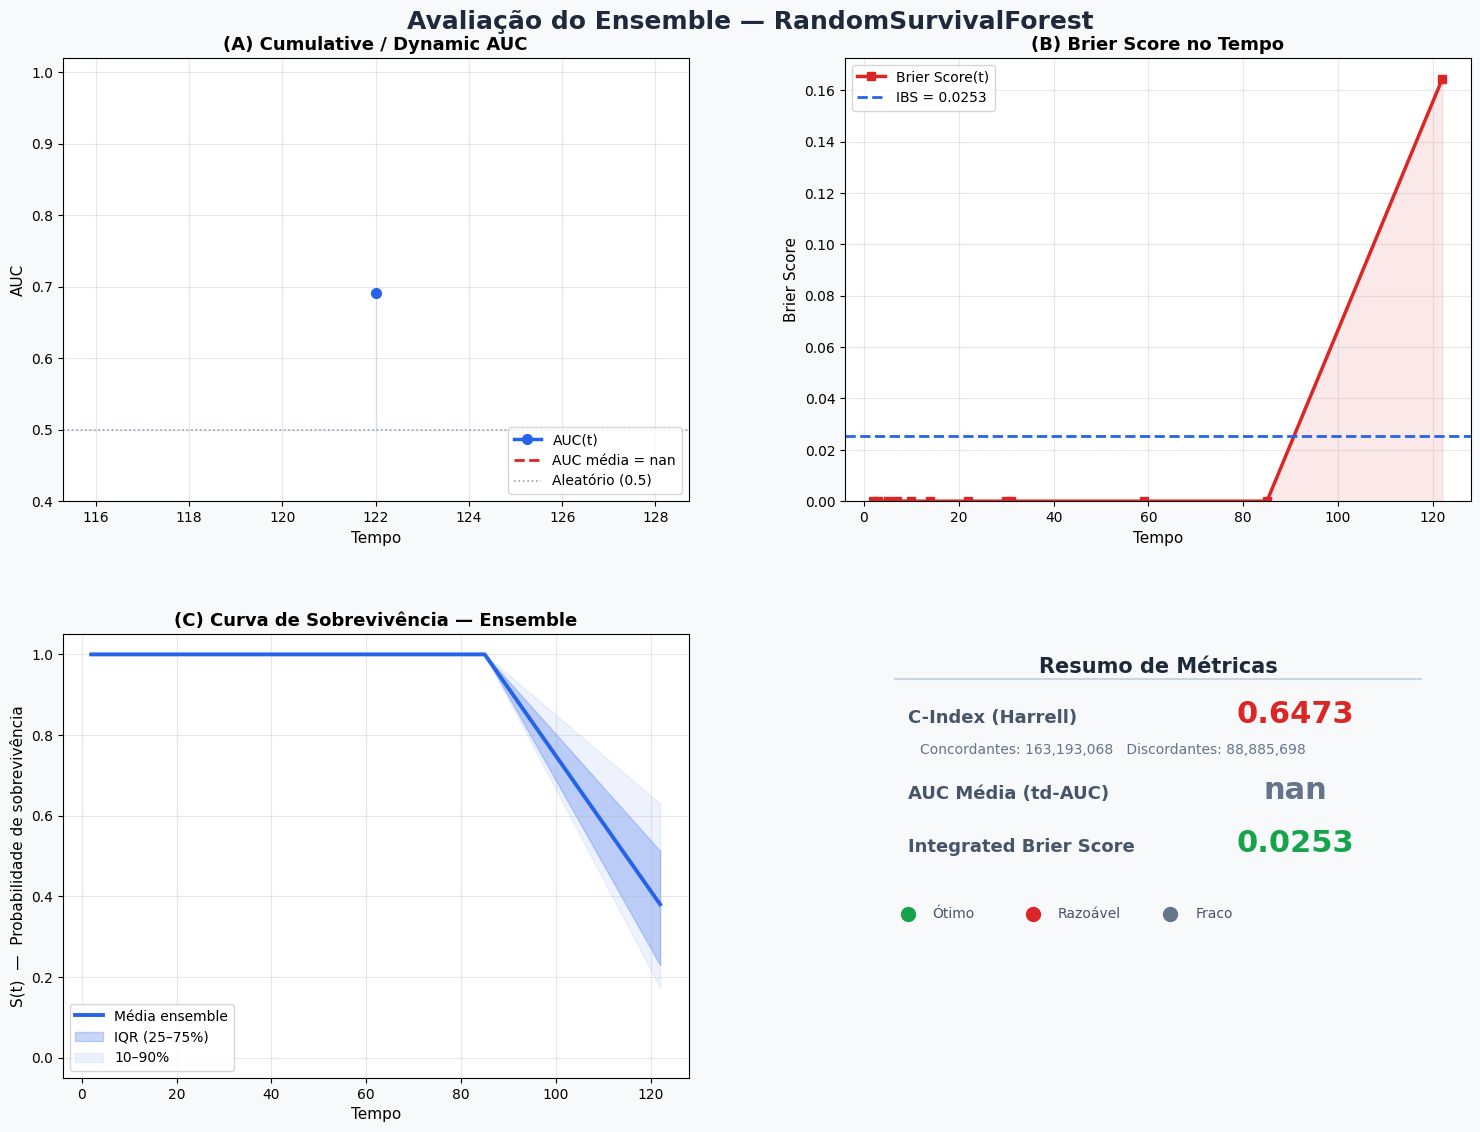

📊 Gráfico salvo: avaliacao_ensemble_rfs.png


In [ ]:
resultados = avaliar_ensemble(
    ensemble_models=ensemble_models,   # saída de train_ensemble_rfs_chunks
    X_test=X_test,
    Y_test=Y_test,                     # structured array sksurv
    Y_train=Y_train,                   # structured array sksurv
)

- Diagnostico do AUC nan

In [ ]:
def diagnosticar_auc(Y_train, Y_test, risk_scores, eval_times):
    """
    Roda todos os checks e imprime exatamente o que está errado.
    Retorna eval_times corrigidos se possível.
    """

    print("=" * 70)
    print("  🔍  DIAGNÓSTICO — AUC NaN")
    print("=" * 70)

    # ── tipos dos structured arrays ─────────────────────────────────────────
    print("\n📌 1. Verificando formato de Y_train / Y_test …")
    for nome, Y in [("Y_train", Y_train), ("Y_test", Y_test)]:
        print(f"   {nome}  →  dtype: {Y.dtype},  shape: {Y.shape}")
        print(f"            campos: {Y.dtype.names}")
        # sksurv espera campo booleano para evento
        campo_evento = Y.dtype.names[0]          # normalmente 'event'
        campo_tempo  = Y.dtype.names[1]          # normalmente 'time'
        print(f"            evento ({campo_evento}): dtype={Y[campo_evento].dtype}  "
              f"| tempo ({campo_tempo}): dtype={Y[campo_tempo].dtype}")

        if Y[campo_evento].dtype != bool:
            print(f"   ⚠️  PROBLEMA: campo de evento não é bool → "
                  f"converta com .astype(bool)")

    # ── ranges de tempo ─────────────────────────────────────────────────────
    print("\n📌 2. Verificando ranges de tempo …")
    train_min = Y_train["time"].min()
    train_max = Y_train["time"].max()
    test_min  = Y_test["time"].min()
    test_max  = Y_test["time"].max()

    print(f"   Y_train  tempo: [{train_min:.4f},  {train_max:.4f}]")
    print(f"   Y_test   tempo: [{test_min:.4f},  {test_max:.4f}]")
    print(f"   eval_times:     [{eval_times.min():.4f},  {eval_times.max():.4f}]")

    # sksurv exige: eval_times dentro do range ESTRITO do TREINO
    # e que exista pelo menos um evento e um controle em cada t
    t_min_valido = train_min          # deve ser > train_min (estrito)
    t_max_valido = train_max          # deve ser < train_max (estrito)

    fora_range = (eval_times <= t_min_valido) | (eval_times >= t_max_valido)
    if fora_range.any():
        print(f"   ⚠️  PROBLEMA: {fora_range.sum()} tempos fora do range do treino!")
        print(f"        tempos inválidos: {eval_times[fora_range]}")

    # ── proporção de eventos (censura) ──────────────────────────────────────
    print("\n📌 3. Verificando proporção de eventos …")
    n_eventos_train = Y_train["event"].astype(bool).sum()
    n_eventos_test  = Y_test["event"].astype(bool).sum()
    pct_train = n_eventos_train / len(Y_train) * 100
    pct_test  = n_eventos_test  / len(Y_test)  * 100

    print(f"   Y_train: {n_eventos_train:,} eventos / {len(Y_train):,} total "
          f"({pct_train:.1f}%)")
    print(f"   Y_test:  {n_eventos_test:,} eventos / {len(Y_test):,} total  "
          f"({pct_test:.1f}%)")

    if pct_test < 5:
        print("   ⚠️  PROBLEMA: proporção de eventos muito baixa no teste → "
              "pode não haver 'cases' em muitos tempos.")

    # ── eventos por faixa de tempo (cases vs controls) ──────────────────────
    print("\n📌 4. Verificando cases/controls em cada eval_time …")
    events_test = Y_test["event"].astype(bool)
    times_test  = Y_test["time"].astype(float)

    problemas_tempo = []
    for t in eval_times:
        cases    = ((times_test <= t) & events_test).sum()   # evento até t
        controls = (times_test > t).sum()                    # sobreviveu além de t
        status   = "✅" if (cases > 0 and controls > 0) else "❌"
        if cases == 0 or controls == 0:
            problemas_tempo.append(t)
            print(f"   {status}  t={t:.4f}  →  cases={cases}, controls={controls}")

    if not problemas_tempo:
        print("   ✅ Todos os tempos têm cases e controls suficientes.")

    # ── risk_scores variância ───────────────────────────────────────────────
    print("\n📌 5. Verificando variância dos risk_scores …")
    var_rs = np.var(risk_scores)
    n_unicos = len(np.unique(risk_scores))
    print(f"   Variância: {var_rs:.6f}  |  valores únicos: {n_unicos}")

    if var_rs == 0 or n_unicos == 1:
        print("   ⚠️  PROBLEMA: todos os risk_scores são iguais → "
              "modelo não discrimina nada.")

    # ── eval_times duplicados ou não ordenados ─────────────────────────────
    print("\n📌 6. Verificando eval_times …")
    if len(eval_times) != len(np.unique(eval_times)):
        print("   ⚠️  PROBLEMA: eval_times tem valores duplicados.")
    if not np.all(eval_times[:-1] < eval_times[1:]):
        print("   ⚠️  PROBLEMA: eval_times não está ordenado crescente.")

    # ── CORRIGINDO eval_times ───────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("  🔧  CORRIGINDO eval_times …")
    print("=" * 70)

    # 1) garante range estrito dentro do treino
    eval_corrigido = eval_times[(eval_times > train_min) & (eval_times < train_max)]

    # 2) remove tempos sem cases ou controls no teste
    mascara_valida = []
    for t in eval_corrigido:
        cases    = ((times_test <= t) & events_test).sum()
        controls = (times_test > t).sum()
        mascara_valida.append(cases > 0 and controls > 0)
    eval_corrigido = eval_corrigido[mascara_valida]

    # 3) ordena e remove duplicatas
    eval_corrigido = np.sort(np.unique(eval_corrigido))

    print(f"   eval_times original : {len(eval_times)} pontos")
    print(f"   eval_times corrigido: {len(eval_corrigido)} pontos")
    print(f"   range corrigido     : [{eval_corrigido.min():.4f}, "
          f"{eval_corrigido.max():.4f}]")

    if len(eval_corrigido) < 2:
        print("\n   ❌ Não foi possível gerar eval_times válidos com os dados "
              "disponíveis.")
        print("      Isso indica censura muito alta ou dados insuficientes no teste.")
        return None

    # ── tenta rodar com os tempos corrigidos ────────────────────────────────
    print("\n⏳ Rodando cumulative_dynamic_auc com tempos corrigidos …")
    try:
        auc_array, mean_auc = cumulative_dynamic_auc(
            survival_train=Y_train,
            survival_test=Y_test,
            estimate=risk_scores,
            times=eval_corrigido,
        )
        print(f"\n✅ SUCESSO!")
        print(f"   AUC média = {mean_auc:.4f}")
        print(f"   AUC por tempo:")
        for t, a in zip(eval_corrigido, auc_array):
            print(f"      t={t:>10.4f}  →  AUC={a:.4f}")
        return eval_corrigido, auc_array, mean_auc

    except Exception as e:
        print(f"\n   ❌ Ainda falhou: {e}")
        return None


In [ ]:
def calcular_auc_temporal_v2(Y_train, Y_test, risk_scores, eval_times=None):
    """
    Versão robusta que filtra eval_times automaticamente
    para evitar NaN.
    """
    train_min = float(Y_train["time"].min())
    train_max = float(Y_train["time"].max())

    events_test = Y_test["event"].astype(bool)
    times_test  = Y_test["time"].astype(float)

    # ── gera eval_times se não fornecido ────────────────────────────────────
    if eval_times is None:
        # usa quantis dos tempos de EVENTO do teste (não todos)
        event_times = times_test[events_test]
        eval_times = np.percentile(event_times, np.linspace(10, 90, 9))

    eval_times = np.sort(np.unique(eval_times.astype(float)))

    # ── filtro 1: range estrito do treino ───────────────────────────────────
    eval_times = eval_times[(eval_times > train_min) & (eval_times < train_max)]

    # ── filtro 2: pelo menos 1 case e 1 control em cada t ──────────────────
    mascara = []
    for t in eval_times:
        cases    = ((times_test <= t) & events_test).sum()
        controls = (times_test > t).sum()
        mascara.append(cases > 0 and controls > 0)
    eval_times = eval_times[mascara]

    if len(eval_times) < 2:
        print("⚠️  Não há tempos válidos suficientes para calcular AUC.")
        return None, None, None

    auc_array, mean_auc = cumulative_dynamic_auc(
        survival_train=Y_train,
        survival_test=Y_test,
        estimate=risk_scores,
        times=eval_times,
    )

    return eval_times, auc_array, mean_auc


In [ ]:
risk_scores = _risk_scores_ensemble(ensemble_models, X_test)
print(f"risk_scores calculados: shape={risk_scores.shape}"
      f"min={risk_scores.min():.4f}, max={risk_scores.max():.4f}")
#
times_test = Y_test["time"].astype(float)
eval_times = np.sort(np.unique(np.percentile(times_test, np.linspace(5,95,20))))
print(f"Eval times gerados: {len(eval_times)} pontos"
      f"[{eval_times.min():.4f} -> {eval_times.max():.4f}]")

diagnosticar_auc(Y_train, Y_test, risk_scores, eval_times)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   26.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   17.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


risk_scores calculados: shape=(265954,)min=102.7930, max=947.4984
Eval times gerados: 13 pontos[1.0000 -> 122.0000]
  🔍  DIAGNÓSTICO — AUC NaN

📌 1. Verificando formato de Y_train / Y_test …
   Y_train  →  dtype: [('event', '?'), ('time', '<f8')],  shape: (797862,)
            campos: ('event', 'time')
            evento (event): dtype=bool  | tempo (time): dtype=float64
   Y_test  →  dtype: [('event', '?'), ('time', '<f8')],  shape: (265954,)
            campos: ('event', 'time')
            evento (event): dtype=bool  | tempo (time): dtype=float64

📌 2. Verificando ranges de tempo …
   Y_train  tempo: [1.0000,  460.0000]
   Y_test   tempo: [1.0000,  389.0000]
   eval_times:     [1.0000,  122.0000]
   ⚠️  PROBLEMA: 1 tempos fora do range do treino!
        tempos inválidos: [1.]

📌 3. Verificando proporção de eventos …
   Y_train: 68,869 eventos / 797,862 total (8.6%)
   Y_test:  22,956 eventos / 265,954 total  (8.6%)

📌 4. Verificando cases/controls em cada eval_time …
   ❌  t=1.0000

[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   25.6s finished


- Necessita corrigir os tempos dos filtros
-

In [ ]:
# =============================================================================
# SOLUÇÃO — eval_times baseados nos EVENTOS OBSERVADOS
# =============================================================================

import numpy as np

print("🔧 Gerando eval_times a partir dos EVENTOS observados …\n")

# ── 1. Pega apenas os tempos onde houve evento (não censura) ────────────────
eventos_test = Y_test["event"].astype(bool)
tempos_evento_test = Y_test["time"][eventos_test].astype(float)

print(f"   Total de eventos no teste: {eventos_test.sum():,}")
print(f"   Range dos tempos de evento: [{tempos_evento_test.min():.4f}, "
      f"{tempos_evento_test.max():.4f}]")

# ── 2. Filtra para ficar dentro do range do TREINO ──────────────────────────
train_min = float(Y_train["time"].min())
train_max = float(Y_train["time"].max())

tempos_evento_validos = tempos_evento_test[
    (tempos_evento_test > train_min) & (tempos_evento_test < train_max)
]

print(f"   Range do treino: [{train_min:.4f}, {train_max:.4f}]")
print(f"   Eventos dentro do range: {len(tempos_evento_validos):,}")

# ── 3. Escolhe quantis desses tempos de evento ──────────────────────────────
if len(tempos_evento_validos) < 10:
    print("\n   ⚠️  Poucos eventos no range válido!")
    # usa todos os eventos disponíveis
    eval_times_corrigido = np.sort(np.unique(tempos_evento_validos))
else:
    # usa 15 quantis dos tempos de evento
    eval_times_corrigido = np.percentile(
        tempos_evento_validos,
        np.linspace(10, 90, 15)
    )
    eval_times_corrigido = np.sort(np.unique(eval_times_corrigido))

print(f"\n✅ eval_times corrigidos: {len(eval_times_corrigido)} pontos")
print(f"   Range: [{eval_times_corrigido.min():.4f}, "
      f"{eval_times_corrigido.max():.4f}]")

# ── 4. Roda o diagnóstico novamente para confirmar ──────────────────────────
print("\n" + "="*70)
print("Rodando diagnóstico com eval_times corrigidos …")
print("="*70)

resultado = diagnosticar_auc(Y_train, Y_test, risk_scores, eval_times_corrigido)

if resultado is not None:
    eval_times_final, auc_array, mean_auc = resultado
    print(f"\n🎉 SUCESSO! AUC média = {mean_auc:.4f}")
else:
    print("\n❌ Ainda há problemas. Veja os detalhes acima.")

# Novo Teste de Acuracidade Random Forest

In [15]:
# =============================================================================
# AVALIAÇÃO COM TEMPOS CUSTOMIZADOS — para datasets com censura alta
# =============================================================================
# Especialmente útil quando os eventos só acontecem após um período longo
# (ex: todos os eventos após 90+ dias)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score,
)


def avaliar_ensemble_tempos_customizados(
    ensemble_models,
    X_test,
    Y_test,
    Y_train,
    tempos_desejados=[120, 150, 180, 240, 300, 360],
    tempo_minimo=90
):
    """
    Avalia o ensemble em tempos específicos.

    Parâmetros
    ----------
    ensemble_models : lista de RSF
    X_test, Y_test, Y_train : dados de teste/treino
    tempos_desejados : list de int/float — tempos para avaliar (dias)
    tempo_minimo : só considera eventos após este tempo (para filtrar censura precoce)
    """

    print("\n" + "=" * 70)
    print("  📊  AVALIAÇÃO COM TEMPOS CUSTOMIZADOS")
    print("=" * 70)

    # ── 1. RISK SCORES ──────────────────────────────────────────────────────
    print("\n⏳ Calculando risk-scores do ensemble …")
    risk_scores = _risk_scores_ensemble(ensemble_models, X_test)
    print(f"   ✅ shape={risk_scores.shape}, range=[{risk_scores.min():.2f}, "
          f"{risk_scores.max():.2f}]")

    # ── 2. ANÁLISE DOS TEMPOS ───────────────────────────────────────────────
    print(f"\n📊 Analisando eventos nos tempos desejados (≥{tempo_minimo} dias) …")

    eventos_test = Y_test["event"].astype(bool)
    tempos_test  = Y_test["time"].astype(float)
    train_min    = float(Y_train["time"].min())
    train_max    = float(Y_train["time"].max())

    print(f"   Range do treino: [{train_min:.0f}, {train_max:.0f}] dias")
    print(f"   Range do teste:  [{tempos_test.min():.0f}, {tempos_test.max():.0f}] dias")
    print(f"   Total de eventos no teste: {eventos_test.sum():,} ({eventos_test.mean()*100:.1f}%)")

    # filtra tempos válidos
    tempos_validos = []
    diagnostico = []

    for t in tempos_desejados:
        # verifica range do treino
        if t <= train_min or t >= train_max:
            diagnostico.append({
                'tempo': t,
                'valido': False,
                'razao': 'fora do range do treino',
                'cases': 0,
                'controls': 0,
            })
            continue

        # verifica cases/controls
        cases    = ((tempos_test <= t) & eventos_test).sum()
        controls = (tempos_test > t).sum()

        valido = (cases >= 10 and controls >= 10)  # exige pelo menos 10 de cada

        diagnostico.append({
            'tempo': t,
            'valido': valido,
            'razao': 'OK' if valido else f'cases={cases}, controls={controls}',
            'cases': cases,
            'controls': controls,
        })

        if valido:
            tempos_validos.append(t)

    # mostra diagnóstico
    print(f"\n   Diagnóstico dos tempos:")
    for d in diagnostico:
        status = "✅" if d['valido'] else "❌"
        print(f"   {status}  {d['tempo']:>3} dias  →  cases={d['cases']:>6,}, "
              f"controls={d['controls']:>6,}  ({d['razao']})")

    if not tempos_validos:
        print("\n   ❌ Nenhum tempo válido encontrado!")
        print("      Sugestão: escolha tempos maiores ou reduza o critério mínimo.")
        return None

    tempos_validos = np.array(tempos_validos, dtype=float)
    print(f"\n   ✅ {len(tempos_validos)} tempos válidos: {tempos_validos}")

    # ── 3. C-INDEX ──────────────────────────────────────────────────────────
    print("\n⏳ Calculando C-Index …")
    result = concordance_index_censored(
        event_indicator=eventos_test,
        event_time=tempos_test,
        estimate=risk_scores,
    )
    c_index_dict = {
        "c_index":      result[0],
        "concordant":   result[1],
        "discordant":   result[2],
        "tied_risk":    result[3],
        "tied_time":    result[4],
    }
    print(f"   ✅ C-Index = {c_index_dict['c_index']:.4f}")

    # ── 4. AUC TEMPORAL ─────────────────────────────────────────────────────
    print("\n⏳ Calculando AUC temporal …")
    try:
        auc_array, mean_auc = cumulative_dynamic_auc(
            survival_train=Y_train,
            survival_test=Y_test,
            estimate=risk_scores,
            times=tempos_validos,
        )
        print(f"   ✅ AUC média = {mean_auc:.4f}")
        auc_sucesso = True
    except Exception as e:
        print(f"   ⚠️  AUC falhou: {e}")
        auc_array = np.full(len(tempos_validos), np.nan)
        mean_auc = np.nan
        auc_sucesso = False

    # ── 5. SOBREVIVÊNCIA DO ENSEMBLE ────────────────────────────────────────
    print("\n⏳ Calculando curvas de sobrevivência …")
    surv_proba = _survival_proba_ensemble(ensemble_models, X_test, tempos_validos)
    print(f"   ✅ shape={surv_proba.shape}")

    # ── 6. BRIER SCORE ──────────────────────────────────────────────────────
    print("\n⏳ Calculando Brier Score …")
    try:
        times_bs, scores_bs = brier_score(
            survival_train=Y_train,
            survival_test=Y_test,
            estimate=surv_proba,
            times=tempos_validos,
        )
        ibs = integrated_brier_score(
            survival_train=Y_train,
            survival_test=Y_test,
            estimate=surv_proba,
            times=tempos_validos,
        )
        print(f"   ✅ IBS = {ibs:.4f}")
        brier_sucesso = True
    except Exception as e:
        print(f"   ⚠️  Brier falhou: {e}")
        times_bs = tempos_validos
        scores_bs = np.full(len(tempos_validos), np.nan)
        ibs = np.nan
        brier_sucesso = False

    # ── 7. RESUMO ───────────────────────────────────────────────────────────
    print("\n" + "─" * 70)
    print("  RESUMO")
    print("─" * 70)
    print(f"   C-Index (Harrell)        : {c_index_dict['c_index']:.4f}")
    if auc_sucesso:
        print(f"   AUC média (td-AUC)       : {mean_auc:.4f}")
    else:
        print(f"   AUC média (td-AUC)       : FALHOU")
    if brier_sucesso:
        print(f"   Integrated Brier Score   : {ibs:.4f}")
    else:
        print(f"   Integrated Brier Score   : FALHOU")
    print("─" * 70)

    print("\n   AUC por tempo:")
    for t, auc in zip(tempos_validos, auc_array):
        print(f"      {t:>3.0f} dias  →  AUC = {auc:.4f}")

    print("\n   Brier Score por tempo:")
    for t, bs in zip(times_bs, scores_bs):
        print(f"      {t:>3.0f} dias  →  BS  = {bs:.4f}")

    # ── 8. PLOTS ────────────────────────────────────────────────────────────
    print("\n⏳ Gerando gráficos …")
    _plotar_resultados_customizados(
        tempos_validos=tempos_validos,
        auc_array=auc_array,
        mean_auc=mean_auc,
        times_bs=times_bs,
        scores_bs=scores_bs,
        ibs=ibs,
        c_index_dict=c_index_dict,
        surv_proba=surv_proba,
    )

    return {
        "c_index":       c_index_dict,
        "tempos":        tempos_validos,
        "auc_array":     auc_array,
        "mean_auc":      mean_auc,
        "brier_scores":  scores_bs,
        "ibs":           ibs,
        "surv_proba":    surv_proba,
    }


# =============================================================================
# HELPERS
# =============================================================================

def _risk_scores_ensemble(models, X_test):
    """Risk-score médio do ensemble."""
    scores = np.column_stack([m.predict(X_test) for m in models])
    return scores.mean(axis=1)


def _survival_proba_ensemble(models, X_test, eval_times):
    """Probabilidade de sobrevivência média do ensemble."""
    all_surv = []
    for m in models:
        chf_funcs = m.predict_cumulative_hazard_function(X_test, return_array=False)
        chf_matrix = np.vstack([fn(eval_times) for fn in chf_funcs])
        surv_matrix = np.exp(-chf_matrix)
        all_surv.append(surv_matrix)
        del chf_funcs, chf_matrix
    return np.mean(all_surv, axis=0)


def _plotar_resultados_customizados(tempos_validos, auc_array, mean_auc,
                                     times_bs, scores_bs, ibs,
                                     c_index_dict, surv_proba):
    """Plot 2x2 com todas as métricas."""

    fig = plt.figure(figsize=(16, 12), facecolor="#f8f9fa")
    gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.25,
                           left=0.07, right=0.95, top=0.92, bottom=0.07)

    CLR_MAIN   = "#2563eb"
    CLR_ACCENT = "#dc2626"
    CLR_OK     = "#16a34a"
    CLR_BG     = "#ffffff"

    fig.suptitle("Avaliação Ensemble — Tempos Customizados (≥90 dias)",
                 fontsize=18, fontweight="bold", color="#1e293b", y=0.96)

    # ── (A) AUC temporal ────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor(CLR_BG)

    if not np.isnan(mean_auc):
        ax1.plot(tempos_validos, auc_array, marker="o", markersize=9,
                 color=CLR_MAIN, linewidth=2.5, label="AUC(t)")
        ax1.axhline(mean_auc, color=CLR_ACCENT, linestyle="--", linewidth=2,
                    label=f"AUC média = {mean_auc:.4f}")
        ax1.axhline(0.5, color="#94a3b8", linestyle=":", linewidth=1.2,
                    label="Aleatório")
        ax1.fill_between(tempos_validos, 0.5, auc_array, alpha=0.12, color=CLR_MAIN)
        ax1.set_ylim(0.4, 1.02)
    else:
        ax1.text(0.5, 0.5, "AUC não disponível", ha="center", va="center",
                 fontsize=14, transform=ax1.transAxes)

    ax1.set_xlabel("Tempo (dias)", fontsize=11)
    ax1.set_ylabel("AUC", fontsize=11)
    ax1.set_title("(A) Cumulative / Dynamic AUC", fontsize=13, fontweight="bold")
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # ── (B) Brier Score ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor(CLR_BG)

    if not np.isnan(ibs):
        ax2.plot(times_bs, scores_bs, marker="s", markersize=7,
                 color=CLR_ACCENT, linewidth=2.5, label="Brier Score(t)")
        ax2.axhline(ibs, color=CLR_MAIN, linestyle="--", linewidth=2,
                    label=f"IBS = {ibs:.4f}")
        ax2.fill_between(times_bs, 0, scores_bs, alpha=0.10, color=CLR_ACCENT)
        ax2.set_ylim(bottom=0)
    else:
        ax2.text(0.5, 0.5, "Brier Score não disponível", ha="center", va="center",
                 fontsize=14, transform=ax2.transAxes)

    ax2.set_xlabel("Tempo (dias)", fontsize=11)
    ax2.set_ylabel("Brier Score", fontsize=11)
    ax2.set_title("(B) Brier Score no Tempo", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # ── (C) Curvas de sobrevivência ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_facecolor(CLR_BG)

    surv_mean = surv_proba.mean(axis=0)
    surv_p10  = np.percentile(surv_proba, 10, axis=0)
    surv_p25  = np.percentile(surv_proba, 25, axis=0)
    surv_p75  = np.percentile(surv_proba, 75, axis=0)
    surv_p90  = np.percentile(surv_proba, 90, axis=0)

    ax3.plot(tempos_validos, surv_mean, color=CLR_MAIN, linewidth=2.8,
             label="Média ensemble")
    ax3.fill_between(tempos_validos, surv_p25, surv_p75,
                     alpha=0.25, color=CLR_MAIN, label="IQR (25–75%)")
    ax3.fill_between(tempos_validos, surv_p10, surv_p90,
                     alpha=0.08, color=CLR_MAIN, label="10–90%")

    ax3.set_xlabel("Tempo (dias)", fontsize=11)
    ax3.set_ylabel("S(t)  —  Prob. Sobrevivência", fontsize=11)
    ax3.set_title("(C) Curva de Sobrevivência — Ensemble", fontsize=13, fontweight="bold")
    ax3.legend(fontsize=10)
    ax3.set_ylim(-0.05, 1.05)
    ax3.grid(True, alpha=0.3)

    # ── (D) Resumo textual ──────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor(CLR_BG)
    ax4.axis("off")

    c_idx = c_index_dict["c_index"]

    def _cor_c(v):   return CLR_OK if v >= 0.7 else (CLR_ACCENT if v >= 0.6 else "#64748b")
    def _cor_auc(v): return CLR_OK if v >= 0.7 else (CLR_ACCENT if v >= 0.6 else "#64748b")
    def _cor_ibs(v): return CLR_OK if v <= 0.15 else (CLR_ACCENT if v <= 0.25 else "#64748b")

    ax4.text(0.5, 0.95, "Resumo de Métricas", ha="center", va="top",
             fontsize=15, fontweight="bold", color="#1e293b", transform=ax4.transAxes)
    ax4.plot([0.08, 0.92], [0.90, 0.90], color="#cbd5e1", linewidth=1.5,
             transform=ax4.transAxes, clip_on=False)

    # C-index
    y = 0.80
    ax4.text(0.10, y, "C-Index (Harrell)", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    ax4.text(0.72, y, f"{c_idx:.4f}", fontsize=22, fontweight="bold",
             color=_cor_c(c_idx), transform=ax4.transAxes, ha="center")

    y -= 0.07
    ax4.text(0.12, y, f"Concordantes: {c_index_dict['concordant']:,}   "
             f"Discordantes: {c_index_dict['discordant']:,}",
             fontsize=10, color="#64748b", transform=ax4.transAxes)

    # AUC média
    y -= 0.10
    ax4.text(0.10, y, "AUC Média (td-AUC)", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    if not np.isnan(mean_auc):
        ax4.text(0.72, y, f"{mean_auc:.4f}", fontsize=22, fontweight="bold",
                 color=_cor_auc(mean_auc), transform=ax4.transAxes, ha="center")
    else:
        ax4.text(0.72, y, "N/A", fontsize=22, fontweight="bold",
                 color="#64748b", transform=ax4.transAxes, ha="center")

    # IBS
    y -= 0.12
    ax4.text(0.10, y, "Integrated Brier Score", fontsize=13, fontweight="bold",
             color="#475569", transform=ax4.transAxes)
    if not np.isnan(ibs):
        ax4.text(0.72, y, f"{ibs:.4f}", fontsize=22, fontweight="bold",
                 color=_cor_ibs(ibs), transform=ax4.transAxes, ha="center")
    else:
        ax4.text(0.72, y, "N/A", fontsize=22, fontweight="bold",
                 color="#64748b", transform=ax4.transAxes, ha="center")

    # legenda semáforo
    y -= 0.14
    ax4.plot([0.10], [y], "o", color=CLR_OK, markersize=10, transform=ax4.transAxes)
    ax4.text(0.14, y, "Ótimo", fontsize=10, color="#475569", va="center", transform=ax4.transAxes)
    ax4.plot([0.30], [y], "o", color=CLR_ACCENT, markersize=10, transform=ax4.transAxes)
    ax4.text(0.34, y, "Razoável", fontsize=10, color="#475569", va="center", transform=ax4.transAxes)
    ax4.plot([0.52], [y], "o", color="#64748b", markersize=10, transform=ax4.transAxes)
    ax4.text(0.56, y, "Fraco", fontsize=10, color="#475569", va="center", transform=ax4.transAxes)

    # tempos avaliados
    y -= 0.12
    ax4.text(0.10, y, f"Tempos avaliados: {list(tempos_validos.astype(int))}",
             fontsize=9, color="#64748b", transform=ax4.transAxes)

    plt.savefig("avaliacao_ensemble_tempos_customizados.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📊 Gráfico salvo: avaliacao_ensemble_tempos_customizados.png")


  📊  AVALIAÇÃO COM TEMPOS CUSTOMIZADOS

⏳ Calculando risk-scores do ensemble …


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   20.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   20.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:   18.6s finished


   ✅ shape=(265954,), range=[102.79, 947.50]

📊 Analisando eventos nos tempos desejados (≥90 dias) …
   Range do treino: [1, 460] dias
   Range do teste:  [1, 389] dias
   Total de eventos no teste: 22,956 (8.6%)

   Diagnóstico dos tempos:
   ✅  120 dias  →  cases= 8,044, controls=14,912  (OK)
   ✅  150 dias  →  cases=12,747, controls=10,209  (OK)
   ✅  180 dias  →  cases=16,148, controls= 6,808  (OK)
   ✅  240 dias  →  cases=20,384, controls= 2,572  (OK)
   ✅  300 dias  →  cases=22,533, controls=   423  (OK)
   ✅  360 dias  →  cases=22,934, controls=    22  (OK)

   ✅ 6 tempos válidos: [120. 150. 180. 240. 300. 360.]

⏳ Calculando C-Index …
   ✅ C-Index = 0.6473

⏳ Calculando AUC temporal …
   ✅ AUC média = 0.7237

⏳ Calculando curvas de sobrevivência …


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    6.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    6.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    6.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    5.6s finished


   ✅ shape=(265954, 6)

⏳ Calculando Brier Score …
   ✅ IBS = 0.0815

──────────────────────────────────────────────────────────────────────
  RESUMO
──────────────────────────────────────────────────────────────────────
   C-Index (Harrell)        : 0.6473
   AUC média (td-AUC)       : 0.7237
   Integrated Brier Score   : 0.0815
──────────────────────────────────────────────────────────────────────

   AUC por tempo:
      120 dias  →  AUC = 0.6750
      150 dias  →  AUC = 0.7013
      180 dias  →  AUC = 0.7458
      240 dias  →  AUC = 0.7876
      300 dias  →  AUC = 0.7881
      360 dias  →  AUC = 0.7550

   Brier Score por tempo:
      120 dias  →  BS  = 0.1575
      150 dias  →  BS  = 0.1677
      180 dias  →  BS  = 0.1414
      240 dias  →  BS  = 0.0753
      300 dias  →  BS  = 0.0191
      360 dias  →  BS  = 0.0047

⏳ Gerando gráficos …


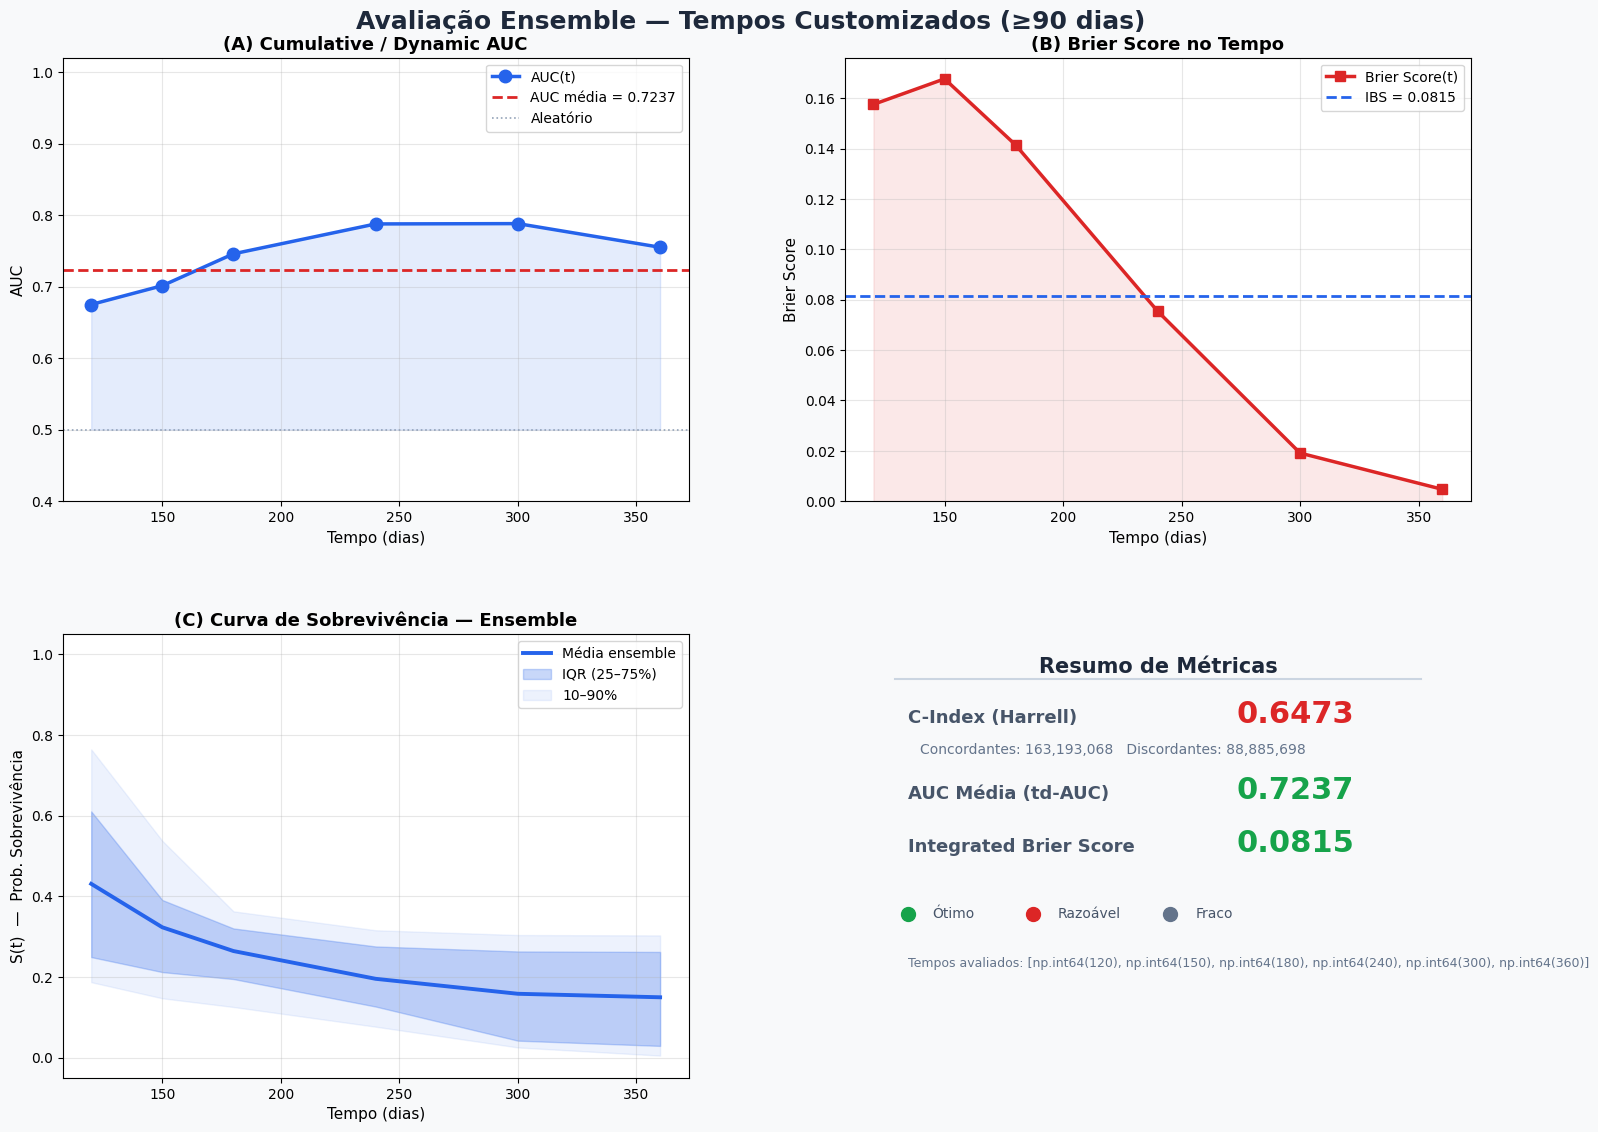

📊 Gráfico salvo: avaliacao_ensemble_tempos_customizados.png


In [16]:
# Importa as funções helper se ainda não tiver no notebook
def _risk_scores_ensemble(models, X_test):
    scores = np.column_stack([m.predict(X_test) for m in models])
    return scores.mean(axis=1)

def _survival_proba_ensemble(models, X_test, eval_times):
    all_surv = []
    for m in models:
        chf_funcs = m.predict_cumulative_hazard_function(X_test, return_array=False)
        chf_matrix = np.vstack([fn(eval_times) for fn in chf_funcs])
        surv_matrix = np.exp(-chf_matrix)
        all_surv.append(surv_matrix)
        del chf_funcs, chf_matrix
    return np.mean(all_surv, axis=0)

# Agora rode a avaliação com os tempos que você pediu
resultados = avaliar_ensemble_tempos_customizados(
    ensemble_models=ensemble_models,
    X_test=X_test,
    Y_test=Y_test,
    Y_train=Y_train,
    tempos_desejados=[120, 150, 180, 240, 300, 360],  # seus tempos
    tempo_minimo=90  # ignora eventos antes de 90 dias
)

- Redigir comparação do bayesiano em relação a modelos tradicionais
- Considerações Finais (tempo do processamento, outras features engineer que poderia ser trabalhadas, etc)
- Sugestões de trabalho futuro;
- Cobrir os pontos fracos do trabalho
- Ficha Catalográfica, Capa, Sumário de Capitulos, de Figuras e Quadros